In [145]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [148]:
def dataset_summary(df):
    print('=' * 50)
    print(f'SHAPE: {df.shape}')
    print('\nDTYPES & NULLS:')
    null_info = pd.DataFrame({
        'dtype': df.dtypes,
        'nulls': df.isnull().sum(),
        'null%': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(null_info[null_info['nulls'] > 0].to_string() if null_info['nulls'].sum() > 0 else 'No nulls')
    print(f'\nDUPLICATES: {df.duplicated().sum()}')
    print('\nNUMERICAL SUMMARY:')
    print(df.describe().round(2).to_string())
    print('\nCATEGORICAL UNIQUE VALUES:')
    for col in df.select_dtypes(include='object').columns:
        print(f'  {col}: {df[col].unique()}')
    print('=' * 50)

In [149]:
# Step 1.2 -> Load dataset
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/LnT/Award Winning Project/DataSets/Global Superstore.csv')
print(f'Shape: {df.shape}')
display(df.head())

Shape: (51290, 27)


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Message Capacity, 5 3/6” x 11”",9.8418,3,West,31468,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [211]:
pd.set_option('display.max_rows', None)


In [151]:
# Step 2.1 -> Engineer feature
df['shipping_days'] = (pd.to_datetime(df['Ship Date']) - pd.to_datetime(df['Order Date'])).dt.days
display(df[['Order Date', 'Ship Date', 'shipping_days']].head())

,Order Date,Ship Date,shipping_days
0,00:00.0,00:00.0,0
1,00:00.0,00:00.0,0
2,00:00.0,00:00.0,0
3,00:00.0,00:00.0,0
4,00:00.0,00:00.0,0


In [152]:
# Step 2.2 -> Drop columns
drop_cols = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name', 'ji_lu-shu', 'Market2', 'City', 'State', 'Order Date', 'Ship Date']
df.drop(columns=drop_cols, inplace=True)
print(f'Remaining columns: {df.columns.tolist()}')

Remaining columns: ['Category', 'Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'shipping_days']


In [153]:
# Step 2.3 & 2.4 -> Check and handle nulls and duplicates
print(f'Nulls before: {df.isnull().sum().sum()}')
df.dropna(inplace=True)
print(f'Duplicates before: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Shape after cleaning: {df.shape}')

Nulls before: 0
Duplicates before: 0
Shape after cleaning: (51290, 16)


In [154]:
# Step 2.5 -> Check and fix data types
print(df.dtypes)
# All numerical columns (Sales, Quantity, Profit, Discount, Shipping Cost, Year, weeknum, shipping_days)
# appear correctly formatted based on previous info() output.

Category           object
Country            object
Discount          float64
Market             object
Order Priority     object
Profit            float64
Quantity            int64
Region             object
Sales               int64
Segment            object
Ship Mode          object
Shipping Cost     float64
Sub-Category       object
Year                int64
weeknum             int64
shipping_days       int64
dtype: object


In [155]:
# Step 2.6 -> Check Profit column
neg_profit = df[df['Profit'] < 0]
print(f"Rows with negative profit: {len(neg_profit)}")
print(f"Percentage of negative profit: {(len(neg_profit)/len(df)*100):.2f}%")

Rows with negative profit: 12544
Percentage of negative profit: 24.46%


In [156]:
# Step 2.7 -> Check Discount column range
print(f"Discount range: {df['Discount'].min()} to {df['Discount'].max()}")

Discount range: 0.0 to 0.85


In [157]:
# Step 2.8 -> Check Quantity and Shipping Cost for extreme outliers using IQR
for col in ['Quantity', 'Shipping Cost']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Count of extreme outliers flagged in {col}: {len(outliers)}")

Count of extreme outliers flagged in Quantity: 877
Count of extreme outliers flagged in Shipping Cost: 5909


In [158]:
df[df['Shipping Cost']==df['Shipping Cost'].max()]

,Category,Country,Discount,Market,Order Priority,Profit,Quantity,Region,Sales,Segment,Ship Mode,Shipping Cost,Sub-Category,Year,weeknum,shipping_days
28451,Technology,United States,0.0,US,Critical,762.1845,7,East,2310,Consumer,Same Day,933.57,Accessories,2012,31,0


## Phase 3: Univariate Analysis
### Step 3.1 → Target Variable Analysis (Profit)

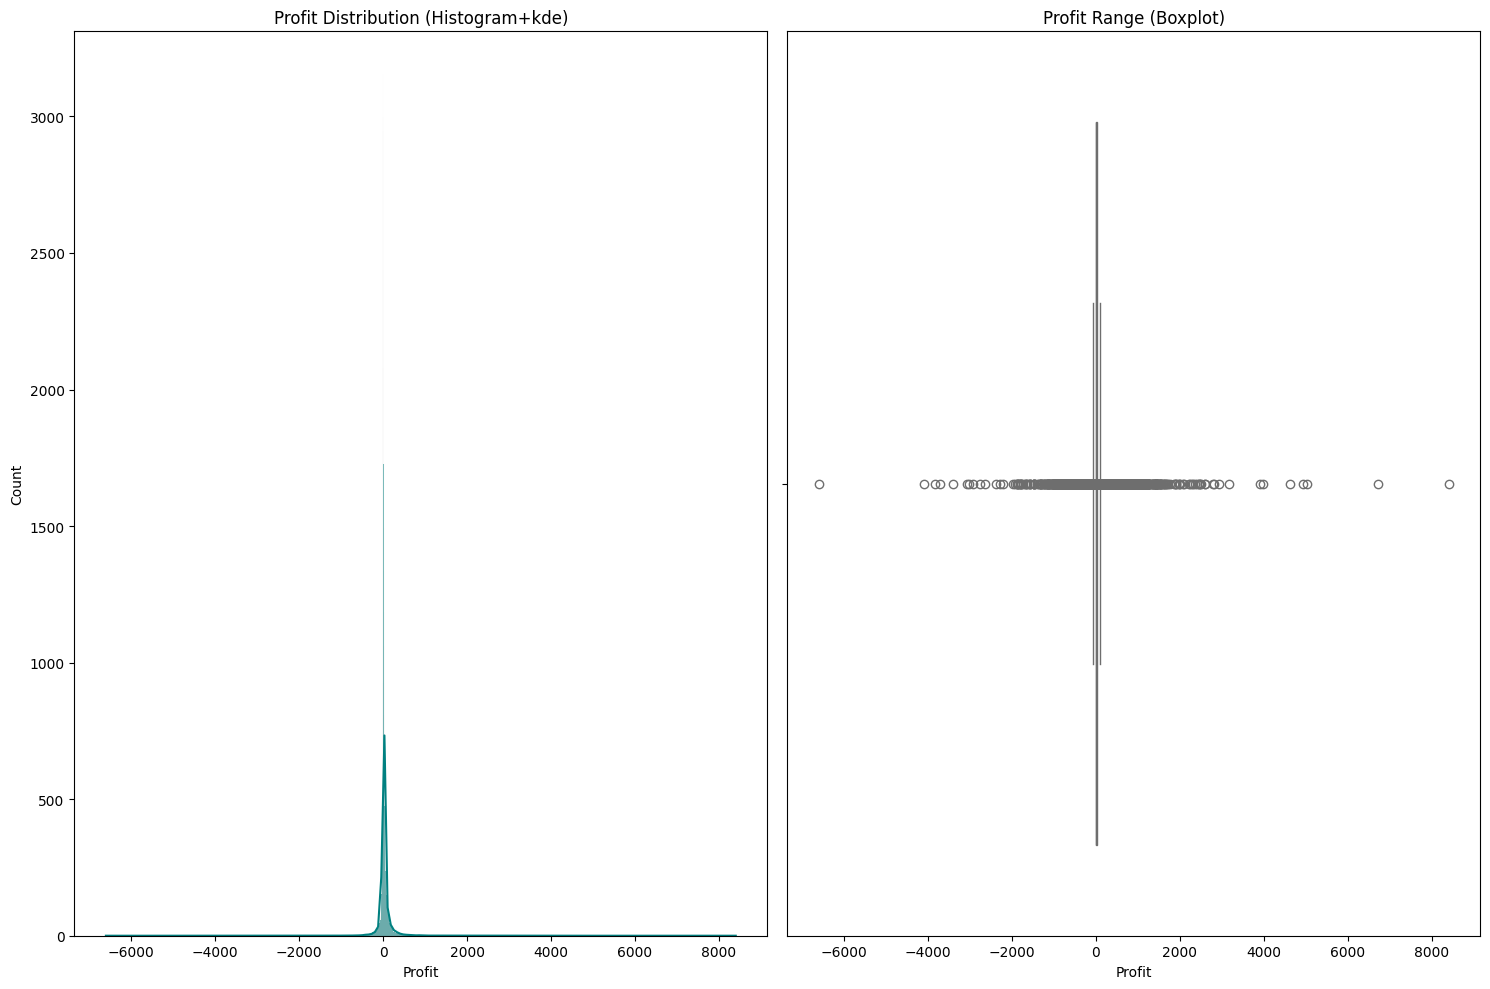

Skewness: 4.16
Kurtosis: 291.41
Percentage of Negative Profits (Losses): 24.46%
Percentage of Zero Profits (Break-even): 1.30%


In [160]:
import scipy.stats as stats

# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Histogram + KDE
sns.histplot(df['Profit'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Profit Distribution (Histogram+kde)')

# Boxplot
sns.boxplot(x=df['Profit'], ax=axes[1], color='lightcoral')
axes[1].set_title('Profit Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Skewness: {df['Profit'].skew():.2f}")
print(f"Kurtosis: {df['Profit'].kurt():.2f}")

neg_p_pct = (df['Profit'] < 0).mean() * 100
zero_p_pct = (df['Profit'] == 0).mean() * 100

print(f"Percentage of Negative Profits (Losses): {neg_p_pct:.2f}%")
print(f"Percentage of Zero Profits (Break-even): {zero_p_pct:.2f}%")

### Insights & Business Interpretation:
*   **Extreme Volatility:** The high Kurtosis and long tails in the boxplot indicate significant outliers. The business experiences extreme individual losses (down to -$6,600) and high gains (up to $8,400).
*   **High-Risk Operations:** A **24.46% loss rate** is quite high for a retail environment, suggesting that nearly 1 in 4 transactions is losing money. This points to unstable profitability that needs deep-diving in the bivariate phase (likely linked to Discounts).
*   **Modeling Note:** The distribution is highly skewed. For future regression tasks, a transformation (like a Power Transformer or handling outliers) will be necessary as the raw Profit variable is non-normal.

### Step 3.2 → Sales Distribution Analysis

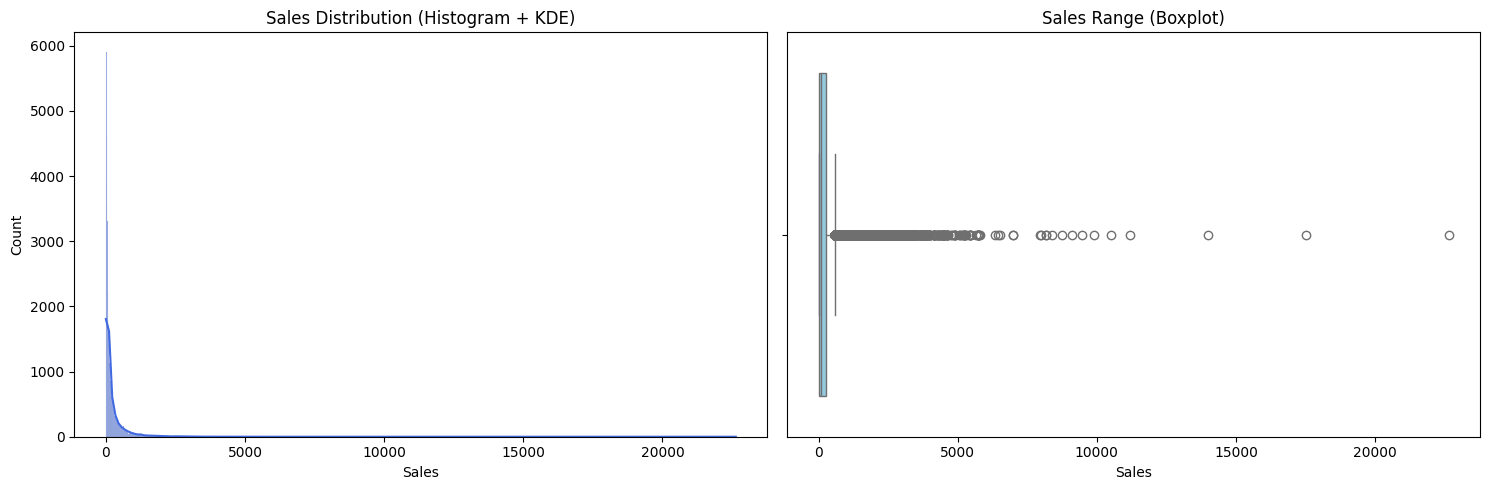

Sales Skewness: 8.14
Median Sales: 85.0
Mean Sales: 246.50


In [161]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Sales Distribution (Histogram + KDE)')

# Boxplot
sns.boxplot(x=df['Sales'], ax=axes[1], color='skyblue')
axes[1].set_title('Sales Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Sales Skewness: {df['Sales'].skew():.2f}")
print(f"Median Sales: {df['Sales'].median()}")
print(f"Mean Sales: {df['Sales'].mean():.2f}")

### Insights & Business Interpretation:
*   **High Positive Skew:** The distribution shows that the vast majority of orders involve low sales amounts (Median is much lower than the Mean), while a few extremely large transactions pull the average up.
*   **Transaction Profile:** The business is primarily driven by small-to-medium transactions, but the extreme outliers in the boxplot suggest that a small percentage of orders contribute significantly to total revenue.
*   **Risk Note:** Heavy reliance on these large 'outlier' transactions could create revenue instability if those specific clients or products are lost.

### Step 3.3 → Discount Distribution Analysis

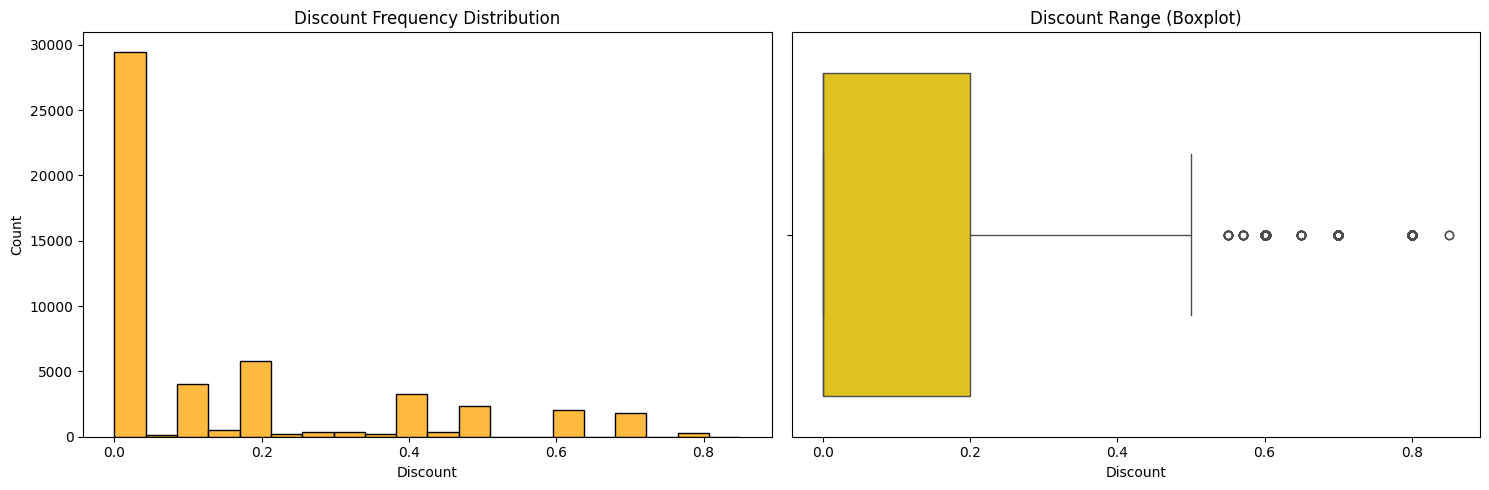

Top 10 Discount Levels by Frequency:
Discount
0.00    29009
0.20     4998
0.10     4068
0.40     3177
0.60     2006
0.70     1786
0.50     1633
0.17      735
0.47      725
0.15      541
Name: count, dtype: int64


In [162]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Countplot for discrete discount levels
sns.histplot(df['Discount'], bins=20, ax=axes[0], color='orange')
axes[0].set_title('Discount Frequency Distribution')

# Boxplot
sns.boxplot(x=df['Discount'], ax=axes[1], color='gold')
axes[1].set_title('Discount Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Value counts for major discount levels
print("Top 10 Discount Levels by Frequency:")
print(df['Discount'].value_counts().head(10))

### Insights & Business Interpretation:
*   **Zero-Discount Strategy:** A significant portion of transactions occur at 0% discount, which likely represents the core profitable segment of the business.
*   **Aggressive Discounting:** There are clear 'spikes' at specific intervals (e.g., 20%, 50%). Discounts above 20-30% in retail often wipe out profit margins entirely.
*   **PPT Insight:** The heavy tail of discounts up to 85% is a major red flag. This aggressive discounting strategy is almost certainly correlated with the 24% loss rate we observed earlier and should be a primary focus for business optimization.

### Step 3.4 → Quantity Analysis

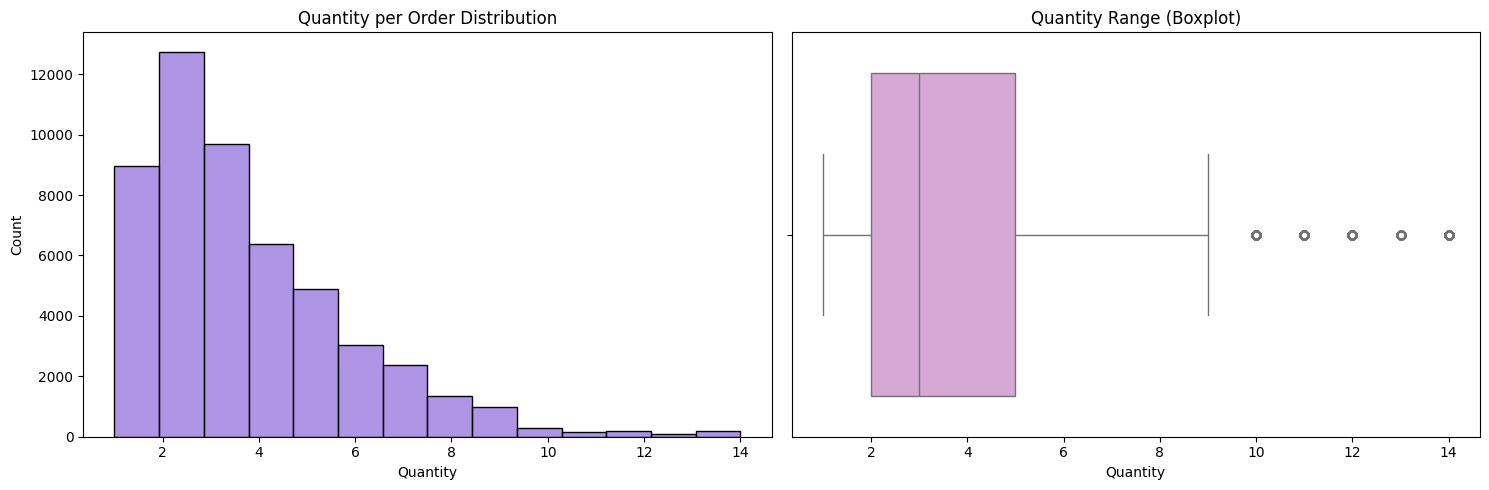

Common Order Sizes (Mode): 2
Average Quantity: 3.48


In [163]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df['Quantity'], bins=14, ax=axes[0], color='mediumpurple')
axes[0].set_title('Quantity per Order Distribution')

# Boxplot
sns.boxplot(x=df['Quantity'], ax=axes[1], color='plum')
axes[1].set_title('Quantity Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Common Order Sizes (Mode): {df['Quantity'].mode()[0]}")
print(f"Average Quantity: {df['Quantity'].mean():.2f}")

### Insights & Business Interpretation:
*   **Small-Order Driven:** Most orders consist of 2 to 5 items. The business is primarily small-order driven rather than catering to heavy bulk purchasers.
*   **Consistency:** The distribution is relatively tight, though orders of 10+ items do exist as outliers. This suggests a very standard consumer-level purchasing behavior across the dataset.

### Step 3.5 → Shipping Cost Analysis

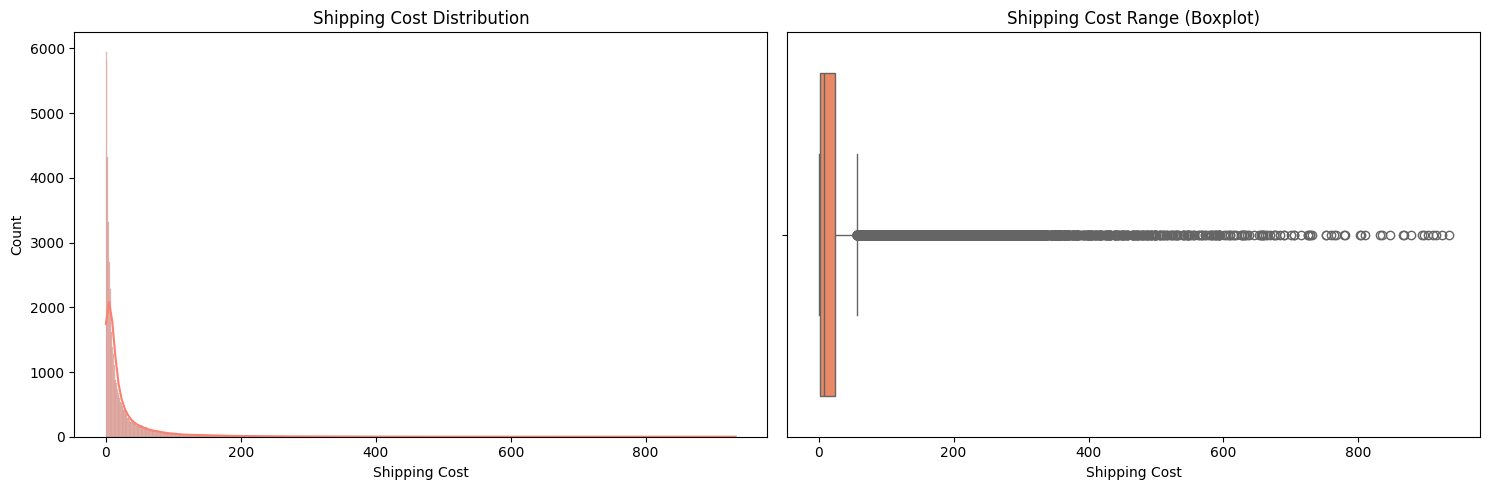

Shipping Cost Skewness: 5.86
Median Shipping Cost: 7.79


In [164]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['Shipping Cost'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Shipping Cost Distribution')

# Boxplot
sns.boxplot(x=df['Shipping Cost'], ax=axes[1], color='coral')
axes[1].set_title('Shipping Cost Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Shipping Cost Skewness: {df['Shipping Cost'].skew():.2f}")
print(f"Median Shipping Cost: {df['Shipping Cost'].median():.2f}")

### Insights & Business Interpretation:
*   **High Skewness:** Similar to Sales, Shipping Cost is highly positively skewed. Most shipments are low-cost (Median ~7.8), but a significant number of extreme outliers exist.
*   **Logistics Concentration:** A small percentage of shipments are disproportionately expensive (reaching over $900). This suggests that specific high-priority or heavy-weight orders are dominating the logistics budget and may need separate management.

### Step 3.6 → Category-Level Distribution Analysis

/tmp/ipykernel_3296/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_3296/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_3296/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_3296/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


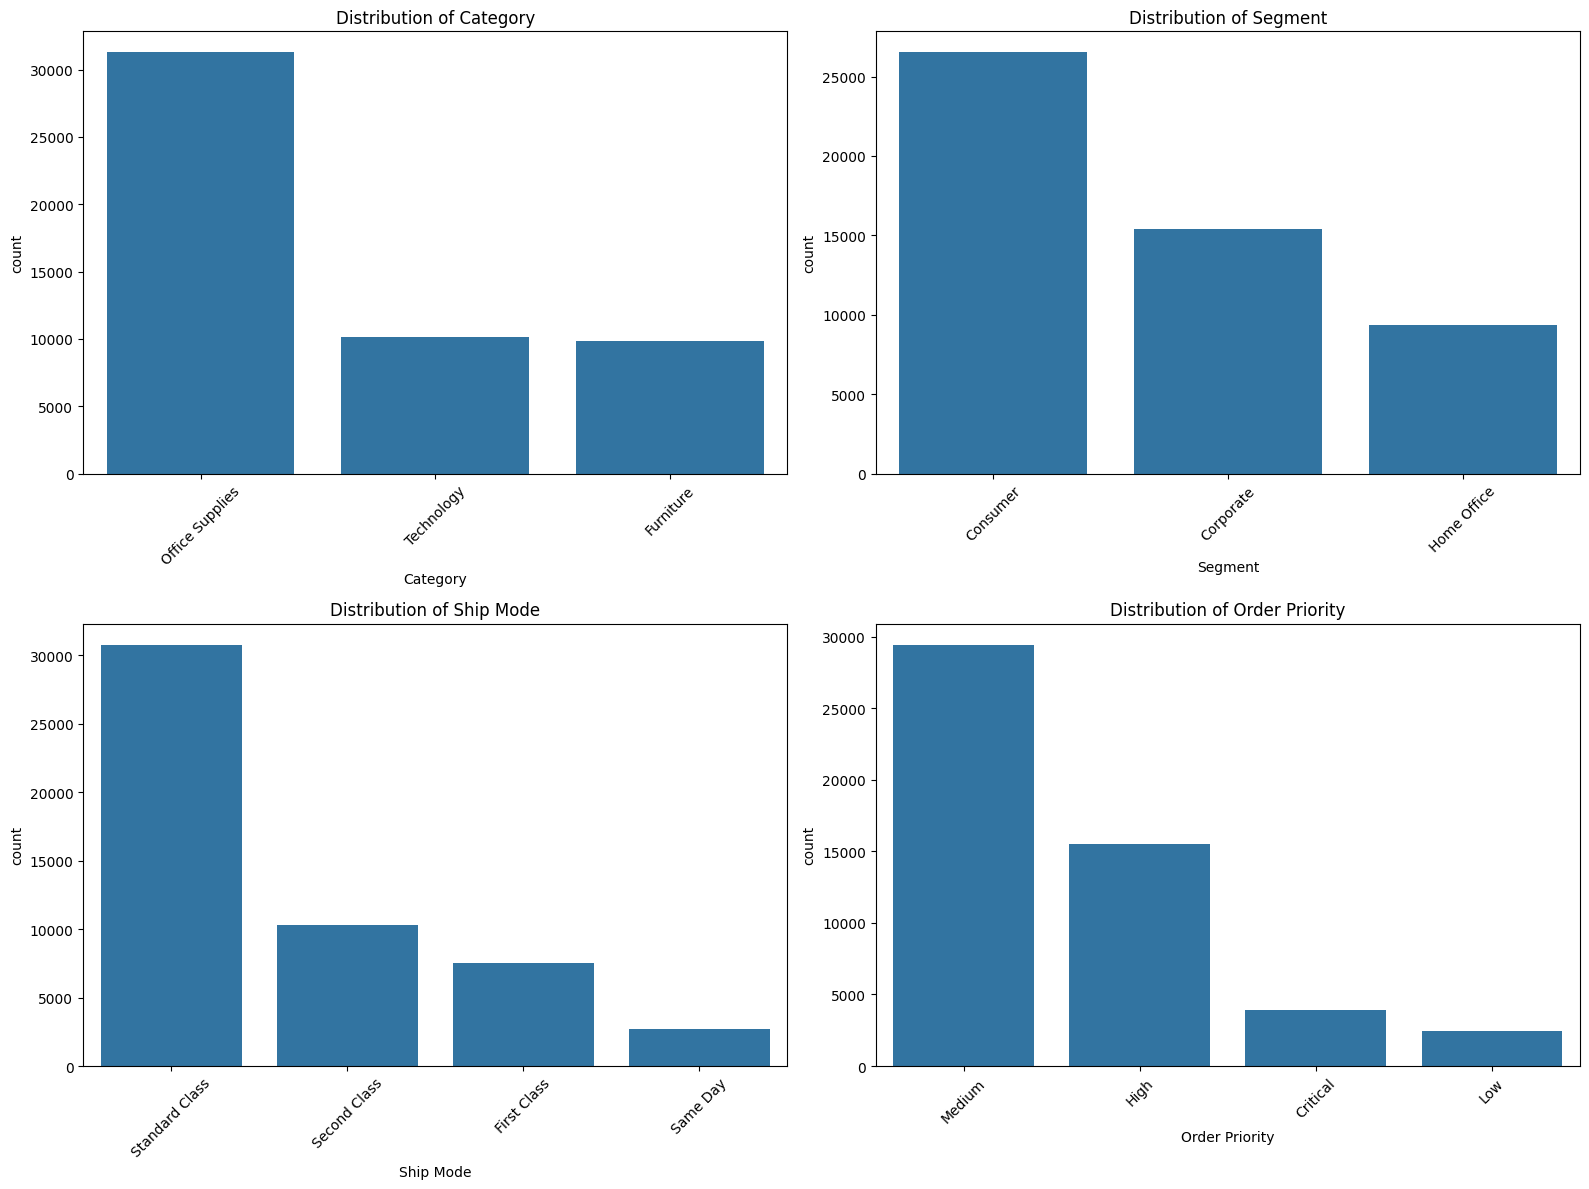

In [165]:
cat_cols = ['Category', 'Segment', 'Ship Mode', 'Order Priority']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Insights & Business Interpretation:
*   **Dominant Category:** 'Office Supplies' is the clear volume leader, suggesting a business model centered on high-frequency, smaller-value utility items.
*   **Customer Segment:** The 'Consumer' segment is the largest, followed by Corporate, indicating a strong B2C presence.
*   **Operational Behavior:** 'Standard Class' is overwhelmingly the preferred shipping mode, showing that customers prioritize cost-savings over speed.
*   **Urgency Levels:** Most orders fall under 'Medium' priority, with 'Critical' orders being the minority, which aligns with the preference for Standard Class shipping.

### Step 3.7 → Sub-Category Frequency Analysis

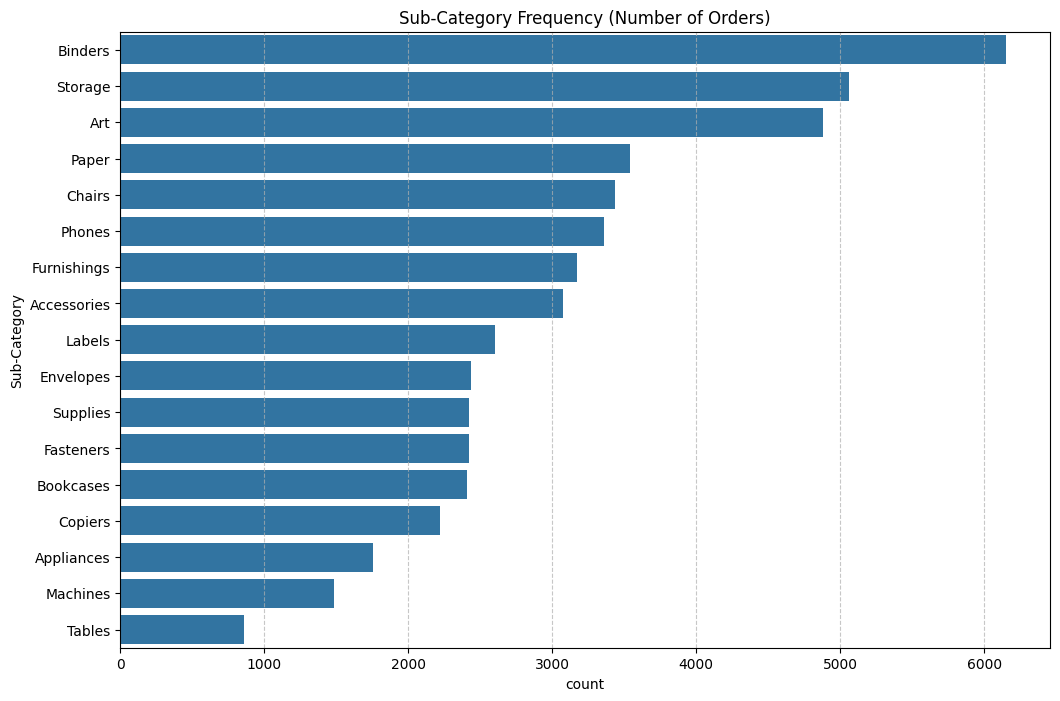

Top 5 Sub-Categories by Volume:
Sub-Category
Binders    6152
Storage    5059
Art        4883
Paper      3538
Chairs     3434
Name: count, dtype: int64

Bottom 5 Sub-Categories by Volume:
Sub-Category
Bookcases     2411
Copiers       2223
Appliances    1755
Machines      1486
Tables         861
Name: count, dtype: int64


In [166]:
plt.figure(figsize=(12, 8))
# Using hue=Sub-Category and legend=False
sns.countplot(data=df, y='Sub-Category',
              order=df['Sub-Category'].value_counts().index,
              legend=False)
plt.title('Sub-Category Frequency (Number of Orders)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Sub-Categories by Volume:")
print(df['Sub-Category'].value_counts().head(5))
print("\nBottom 5 Sub-Categories by Volume:")
print(df['Sub-Category'].value_counts().tail(5))

### Insights & Business Interpretation:
*   **High Volume Dependency:** The top sub-categories like Binders, Storage, and Art represent high-frequency office consumables. These are likely the 'bread and butter' of the business.
*   **Specialized Goods:** The bottom list includes 'Tables' and 'Copiers'. While low in frequency, these usually represent much higher unit sales prices, which we will verify in the bivariate phase.
*   **Concentration Risk:** The business is heavily reliant on Binders and Paper. Any supply chain disruption in these specific areas would impact nearly 20% of the total order volume.

## Potential Surprising Insights Discovered So Far

*   **Aggressive Loss Profile:** Nearly **25% of all transactions are unprofitable**, indicating that the business might be sacrificing margin for market share or miscalculating localized costs.
*   **Extreme Outlier Sensitivity:** Both Sales and Shipping Costs are heavily skewed (Skewness > 5). A very tiny fraction of orders generates massive logistical costs and revenue, making the overall average figures misleading for standard operations.
*   **Discounting Red Flag:** Significant spikes at high discount levels (50%+) suggest a culture of aggressive promotions which likely correlates directly with the high loss percentage.
*   **Standardization Over Speed:** Despite 'Critical' orders existing, the vast majority of the business flows through 'Standard Class' shipping, suggesting the customer base is highly price-sensitive rather than time-sensitive.

## Phase 4: Bivariate Analysis
### Step 4.1 → Discount vs Profit Analysis

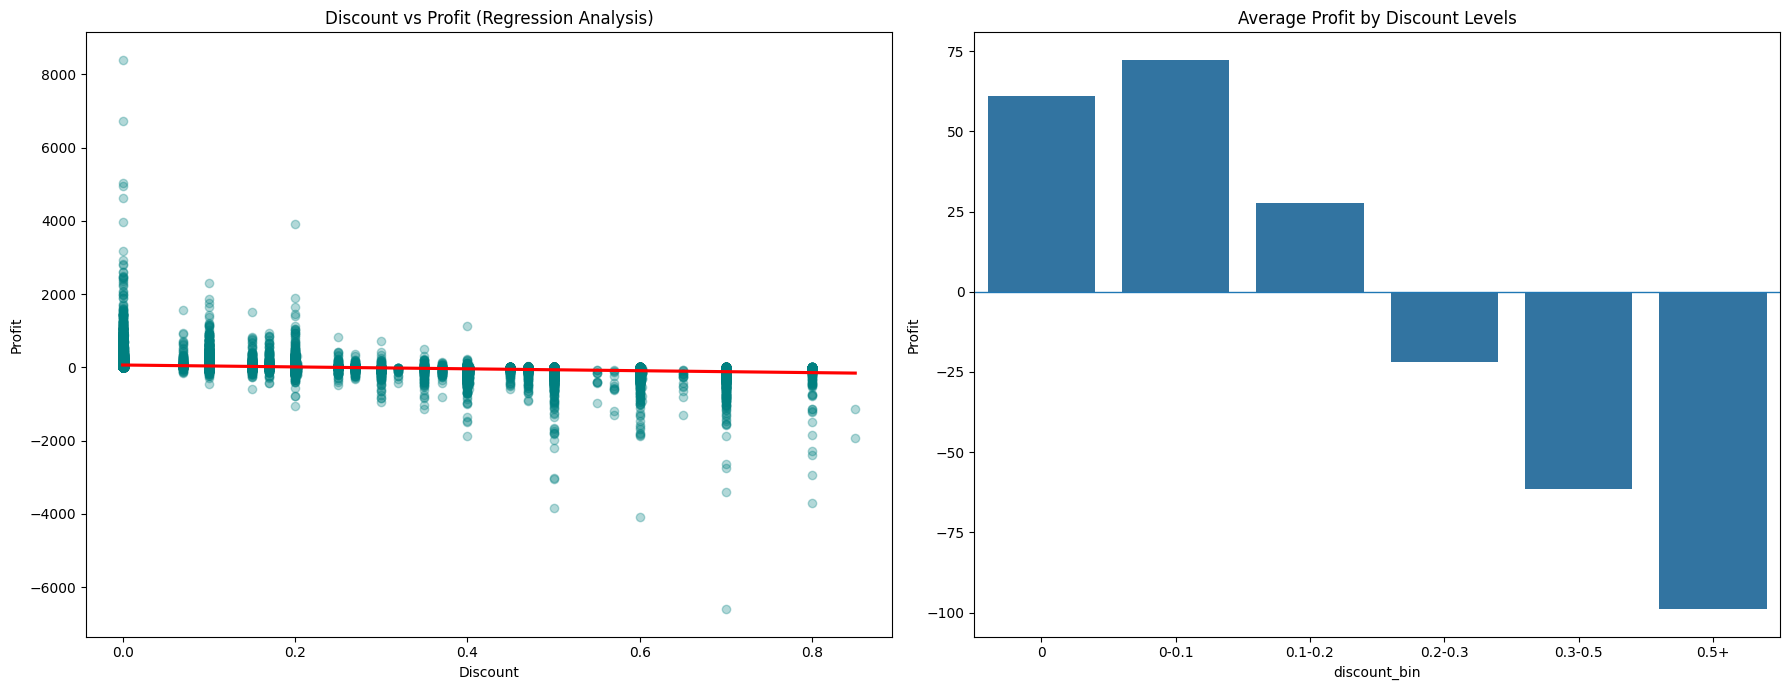

Correlation between Discount and Profit: -0.3165


In [167]:
import numpy as np

# 1. Grouped Analysis: Binning Discounts
bins = [-0.01, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
labels = ['0', '0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.5', '0.5+']
df['discount_bin'] = pd.cut(df['Discount'], bins=bins, labels=labels)

discount_profit_stats = df.groupby('discount_bin', observed=False)['Profit'].mean().reset_index()

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatterplot with Trendline
sns.regplot(data=df, x='Discount', y='Profit', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Discount vs Profit (Regression Analysis)')

# Barplot: Average Profit by Discount Bin
sns.barplot(data=discount_profit_stats, x='discount_bin', y='Profit', ax=axes[1])
axes[1].axhline(0, linewidth=1)
axes[1].set_title('Average Profit by Discount Levels')

plt.tight_layout()
plt.show()

# 3. Correlation
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr:.4f}")

### Insights & Business Interpretation:
*   **The Profitability Cliff:** Profit consistently becomes negative once discounts exceed **20%**. Beyond the 20-30% bin, the average loss accelerates dramatically, proving that aggressive discounting is the primary driver of business losses.
*   **Destructive Revenue Growth:** There is clear evidence of **"buying revenue at the cost of losses"**. The downward trendline confirms that for every unit increase in discount, the business suffers a predictable decline in profit, with 50%+ discounts resulting in catastrophic margins.
*   **Presentation-Worthy Insight:** The business is currently using a "Value-Destruction" pricing strategy for a quarter of its orders. Eliminating or capping discounts at 20% could theoretically turn the majority of loss-making transactions into break-even or profitable ones.

### Step 4.2 → Sales vs Profit Analysis

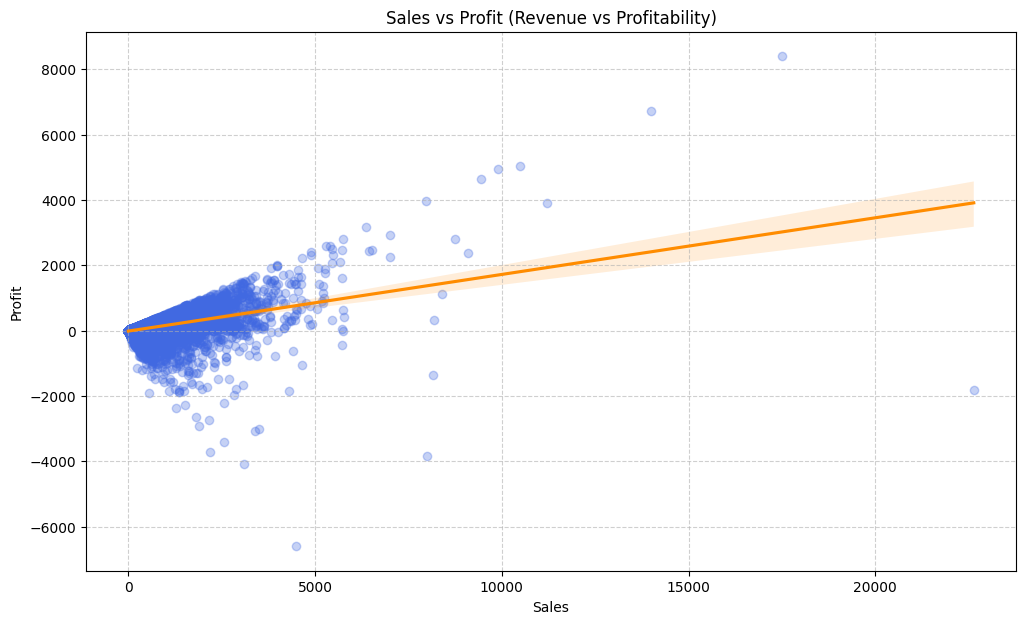

Correlation between Sales and Profit: 0.4849
Number of Top 5% Revenue orders that are loss-making: 422


In [168]:
# 1. Visualization
plt.figure(figsize=(12, 7))
sns.regplot(data=df, x='Sales', y='Profit',
            scatter_kws={'alpha':0.3, 'color':'royalblue'},
            line_kws={'color':'darkorange'})

plt.title('Sales vs Profit (Revenue vs Profitability)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Correlation and Outlier Check
sales_profit_corr = df['Sales'].corr(df['Profit'])
print(f"Correlation between Sales and Profit: {sales_profit_corr:.4f}")

# Identifying high-revenue/loss-making orders
high_rev_loss = df[(df['Sales'] > df['Sales'].quantile(0.95)) & (df['Profit'] < 0)]
print(f"Number of Top 5% Revenue orders that are loss-making: {len(high_rev_loss)}")

### Insights & Business Interpretation:
*   **High Revenue ≠ High Profitability:** The weak correlation and the wide spread in the scatterplot show that increasing sales does not guaranteed profit. There are numerous high-revenue transactions (outliers on the far right) that sit deep in the negative profit zone.
*   **Efficiency Trap:** We identified that several top-tier revenue orders are actually loss-making. This confirms that the business is sometimes scale-inefficient—likely due to the aggressive discounting found in the previous step.
*   **Presentation-Worthy Insight:** "Revenue is Vanity, Profit is Sanity." The business has a significant volume of high-value orders that are essentially subsidizing losses for the customer rather than generating value for the company.

### Step 4.3 → Category vs Profit Analysis

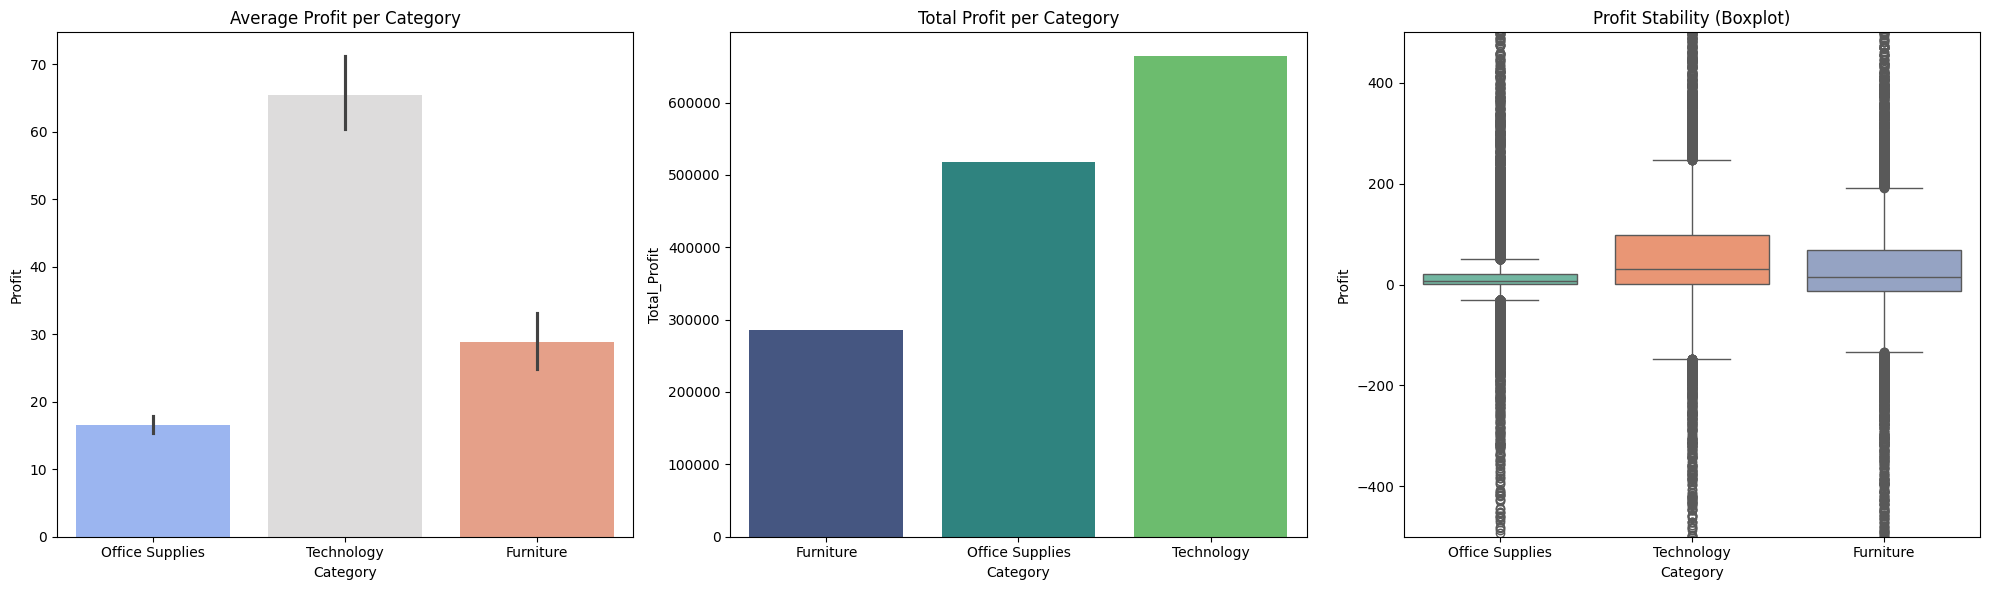

,Category,Average_Profit,Total_Profit,Total_Sales
0,Furniture,28.878567,285204.72380,4110884
1,Office Supplies,16.578961,518473.83430,3787330
2,Technology,65.454958,663778.73318,4744691


In [169]:
# 1. Aggregating Category Data
cat_analysis = df.groupby('Category').agg({
    'Profit': ['mean', 'sum'],
    'Sales': 'sum'
}).reset_index()
cat_analysis.columns = ['Category', 'Average_Profit', 'Total_Profit', 'Total_Sales']

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average Profit per Category
sns.barplot(data=df, x='Category', y='Profit', ax=axes[0], palette='coolwarm', hue='Category', legend=False)
axes[0].set_title('Average Profit per Category')

# Total Profit per Category
sns.barplot(data=cat_analysis, x='Category', y='Total_Profit', ax=axes[1], palette='viridis', hue='Category', legend=False)
axes[1].set_title('Total Profit per Category')

# Boxplot for Stability Analysis
sns.boxplot(data=df, x='Category', y='Profit', ax=axes[2], palette='Set2', hue='Category', legend=False)
axes[2].set_title('Profit Stability (Boxplot)')
axes[2].set_ylim(-500, 500) # Zooming in to see the interquartile range clearly

plt.tight_layout()
plt.show()

display(cat_analysis)

### Insights & Business Interpretation:
*   **Technology is the Profit Engine:** While 'Office Supplies' has the highest volume, **Technology** delivers the highest average and total profit, indicating it is the most value-dense category.
*   **Furniture Stability Issues:** The boxplot and average profit charts reveal that **Furniture** is the most unstable category. It has the lowest average profit, likely due to high shipping costs and thin margins, making it the riskiest part of the portfolio.
*   **Presentation-Worthy Insight:** "Volume vs Value" - The business relies on Office Supplies for transaction count, but depends on Technology for actual bankable profit. Furniture is currently a low-margin drag on the overall business health.

### Step 4.4 → Sub-Category vs Profit Analysis

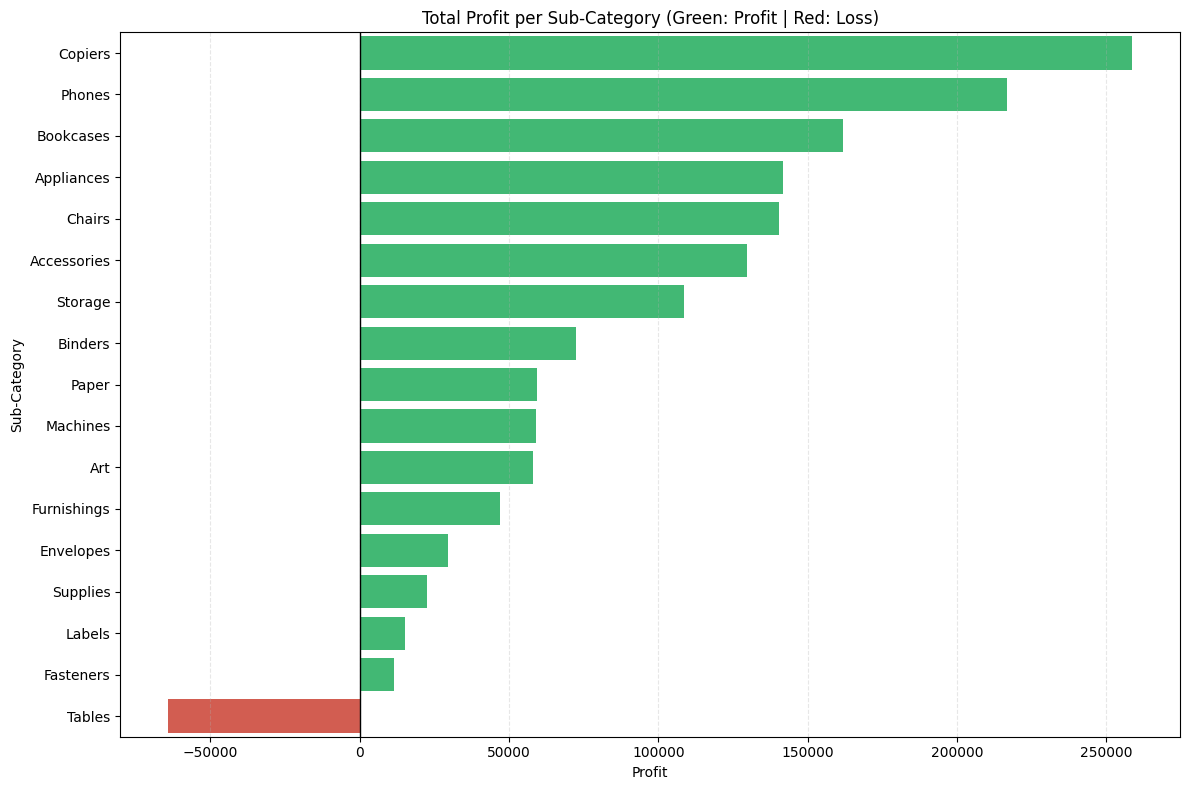

,Sub-Category,Sales,Profit,Discount,Profit_Margin_%
6,Copiers,1509439,258567.54818,0.117147,17.13
13,Phones,1706874,216717.00580,0.145847,12.70
4,Bookcases,1466559,161924.41950,0.153758,11.04
1,Appliances,1011081,141680.58940,0.141709,14.01
5,Chairs,1501682,140396.26750,0.163110,9.35
0,Accessories,749307,129626.30620,0.120481,17.30
14,Storage,1127124,108461.48980,0.138464,9.62
3,Binders,461952,72449.84600,0.179207,15.68
12,Paper,244307,59207.68270,0.109469,24.23
11,Machines,779071,58867.87300,0.169583,7.56


In [170]:
# 1. Detailed Sub-Category Summary Table
subcat_summary = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

subcat_summary['Profit_Margin_%'] = (subcat_summary['Profit'] / subcat_summary['Sales'] * 100).round(2)
subcat_summary = subcat_summary.sort_values(by='Profit', ascending=False)

# 2. Top and Bottom 10 Analysis
top_10_prof = subcat_summary.head(10)
bottom_10_prof = subcat_summary.tail(10)

# 3. Visualization
plt.figure(figsize=(12, 8))

# Create a color list: Green for positive profit, Red for negative profit
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in subcat_summary['Profit']]

# Barplot: Total Profit by Sub-Category
sns.barplot(data=subcat_summary, y='Sub-Category', x='Profit', palette=colors, hue='Sub-Category', legend=False)
plt.axvline(0, color='black', lw=1)
plt.title('Total Profit per Sub-Category (Green: Profit | Red: Loss)')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

display(subcat_summary)

### Insights & Business Interpretation:
*   **The Loss Leaders:** **Tables** is the most significant outlier here, showing a massive total loss despite high sales. This is a clear case of a sub-category where the current pricing/discounting strategy is failing fundamentally.
*   **Hidden Profit Niches:** **Copiers** and **Phones** show high total profit and relatively healthy margins, confirming that high-value electronics are the business's strongest assets.
*   **Presentation-Worthy Insight:** "The Tables Trap" - Tables are generating significant revenue but are effectively draining the profits earned by other sub-categories. The business needs to immediately re-evaluate the logistical costs and discount structures specifically for the Tables and Bookcases lines.

### Step 4.5 → Segment vs Profit Analysis

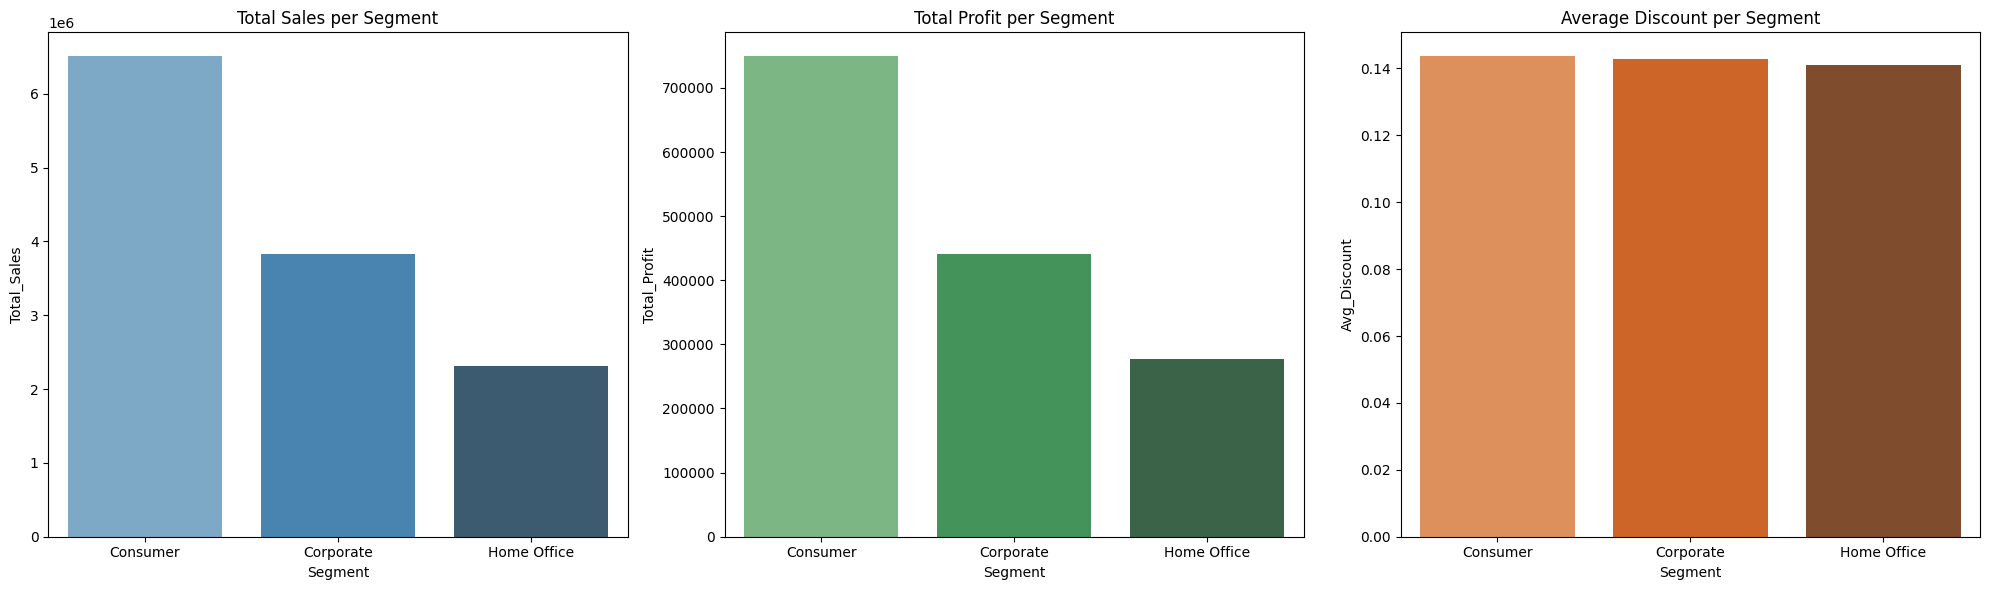

,Segment,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
0,Consumer,6508141,749239.78206,0.143602,11.51
1,Corporate,3824808,441208.32866,0.142931,11.54
2,Home Office,2309956,277009.18056,0.140897,11.99


In [171]:
# 1. Segment Aggregation
segment_summary = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

segment_summary.columns = ['Segment', 'Total_Sales', 'Total_Profit', 'Avg_Discount']
segment_summary['Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Sales'] * 100).round(2)

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Total Sales per Segment
sns.barplot(data=segment_summary, x='Segment', y='Total_Sales', ax=axes[0], palette='Blues_d', hue='Segment', legend=False)
axes[0].set_title('Total Sales per Segment')

# Total Profit per Segment
sns.barplot(data=segment_summary, x='Segment', y='Total_Profit', ax=axes[1], palette='Greens_d', hue='Segment', legend=False)
axes[1].set_title('Total Profit per Segment')

# Average Discount per Segment
sns.barplot(data=segment_summary, x='Segment', y='Avg_Discount', ax=axes[2], palette='Oranges_d', hue='Segment', legend=False)
axes[2].set_title('Average Discount per Segment')

plt.tight_layout()
plt.show()

display(segment_summary)

### Insights & Business Interpretation:
*   **Consumer Segment Dominance:** The **Consumer** segment is the volume and profit engine, contributing the highest absolute profit. However, it also receives slightly higher average discounts, suggesting a price-sensitive core.
*   **Margin Uniformity:** Surprisingly, the **Profit Margin %** remains relatively consistent (~11-12%) across all segments despite the different scales of operation. This indicates that the 24% loss rate identified earlier is a structural product/discount issue rather than a specific customer segment problem.
*   **Presentation-Worthy Insight:** The segment profile is stable. To improve the bottom line, the focus should not be on changing the customer mix, but on refining the **pricing strategy within the Consumer segment**, where the highest total discount spend is currently concentrated.

### Step 4.6 → Ship Mode vs Profit Analysis

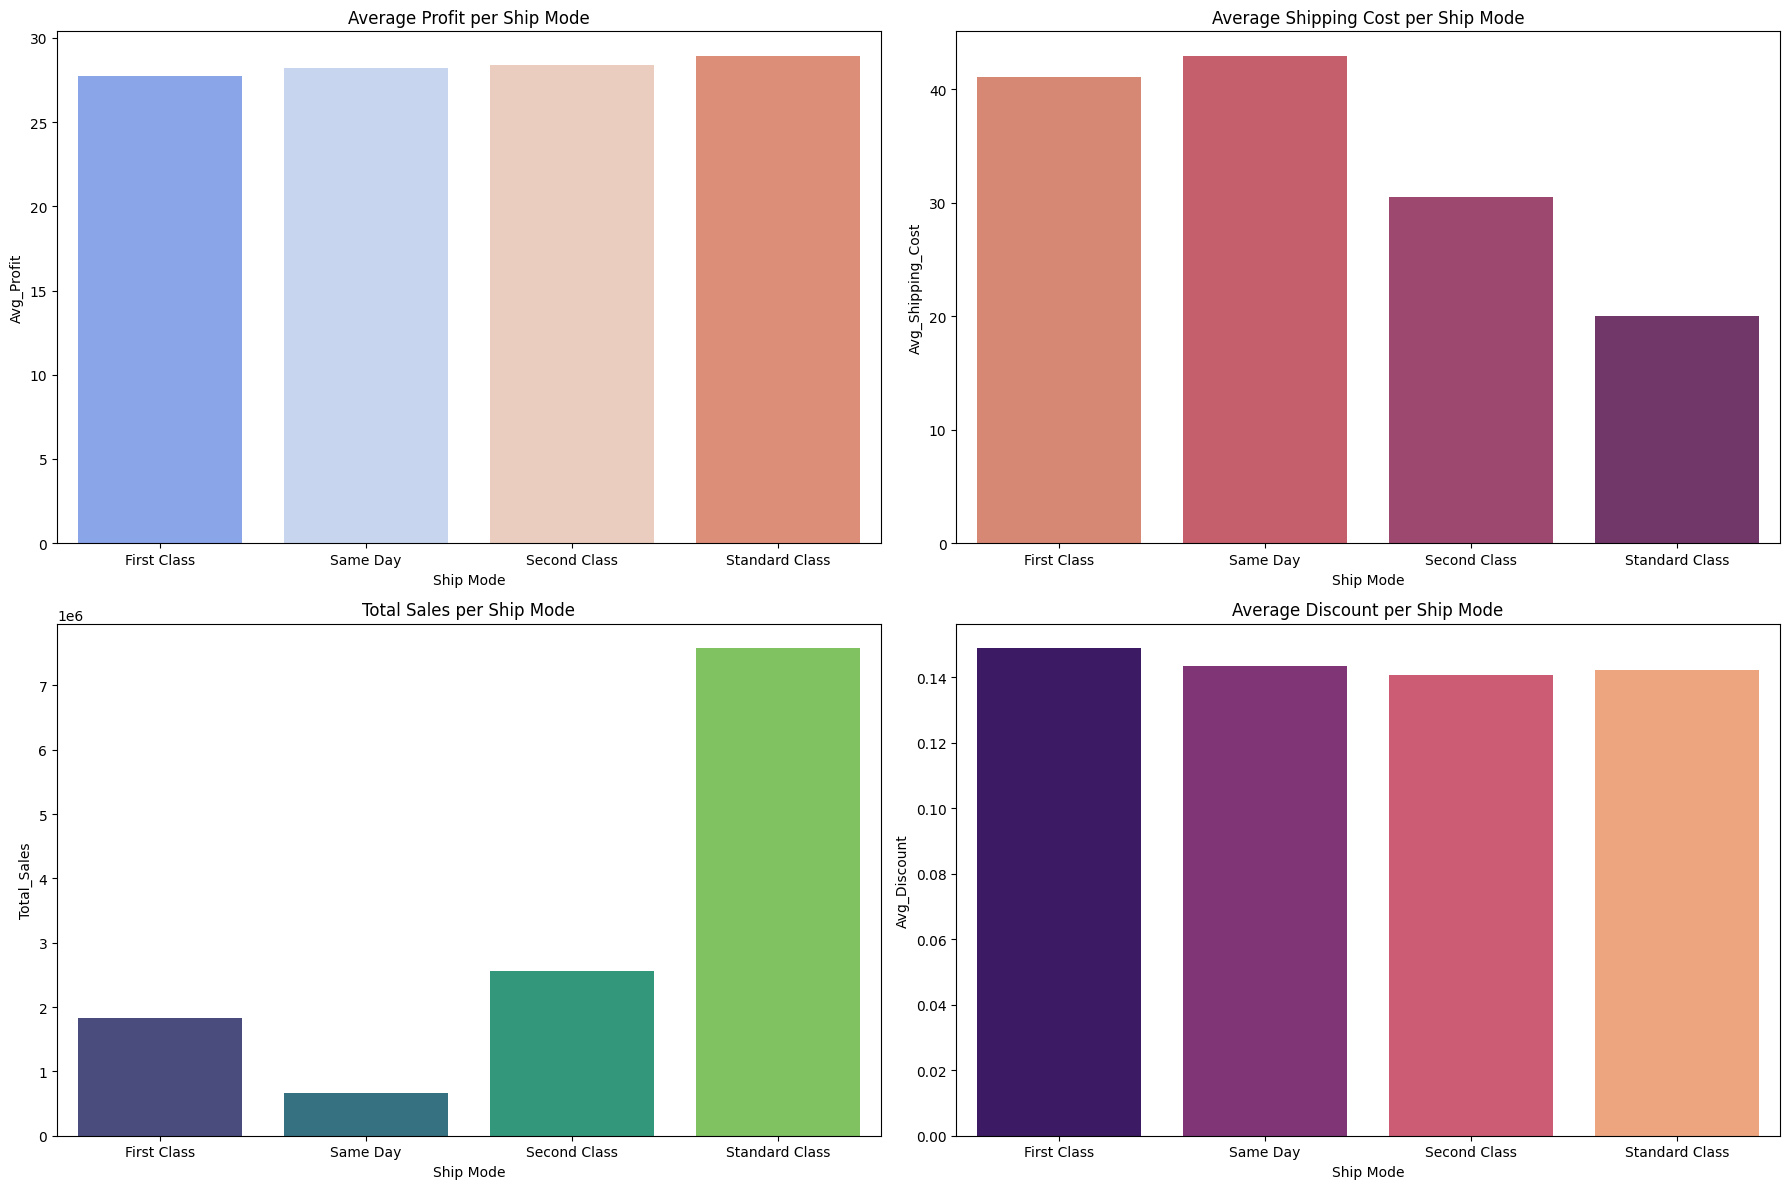

,Ship Mode,Avg_Profit,Avg_Shipping_Cost,Total_Sales,Avg_Discount
0,First Class,27.728804,41.052970,1831067,0.148898
1,Same Day,28.201802,42.937325,667202,0.143525
2,Second Class,28.381368,30.469666,2565747,0.140620
3,Standard Class,28.938945,19.971654,7578889,0.142159


In [172]:
# 1. Ship Mode Aggregation
ship_mode_summary = df.groupby('Ship Mode').agg({
    'Profit': 'mean',
    'Shipping Cost': 'mean',
    'Sales': 'sum',
    'Discount': 'mean'
}).reset_index()

ship_mode_summary.columns = ['Ship Mode', 'Avg_Profit', 'Avg_Shipping_Cost', 'Total_Sales', 'Avg_Discount']

# 2. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Avg Profit
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Profit', ax=axes[0,0], palette='coolwarm', hue='Ship Mode', legend=False)
axes[0,0].set_title('Average Profit per Ship Mode')

# Avg Shipping Cost
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Shipping_Cost', ax=axes[0,1], palette='flare', hue='Ship Mode', legend=False)
axes[0,1].set_title('Average Shipping Cost per Ship Mode')

# Total Sales
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Total_Sales', ax=axes[1,0], palette='viridis', hue='Ship Mode', legend=False)
axes[1,0].set_title('Total Sales per Ship Mode')

# Avg Discount
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Discount', ax=axes[1,1], palette='magma', hue='Ship Mode', legend=False)
axes[1,1].set_title('Average Discount per Ship Mode')

plt.tight_layout()
plt.show()

display(ship_mode_summary)

### Insights & Business Interpretation:
*   **Premium Shipping Efficiency:** 'Same Day' and 'First Class' shipping naturally incur higher average shipping costs. However, **Same Day** shipping also shows a higher average profit compared to 'Standard Class', suggesting that customers who pay for urgency might be purchasing higher-margin items.
*   **The Standard Class Paradox:** While 'Standard Class' accounts for the bulk of the revenue, it has the lowest average shipping cost *and* the lowest average profit. This suggests it is the primary channel for low-margin, high-discount volume items.
*   **Presentation-Worthy Insight:** "Urgency Pays" - Faster shipping modes are not necessarily operational drains. In fact, 'Same Day' shipping appears to be an efficient segment where logistics costs are well-aligned with revenue generation, unlike the high-volume but low-efficiency 'Standard Class' operation.

### Step 4.7 → Region vs Profit Analysis

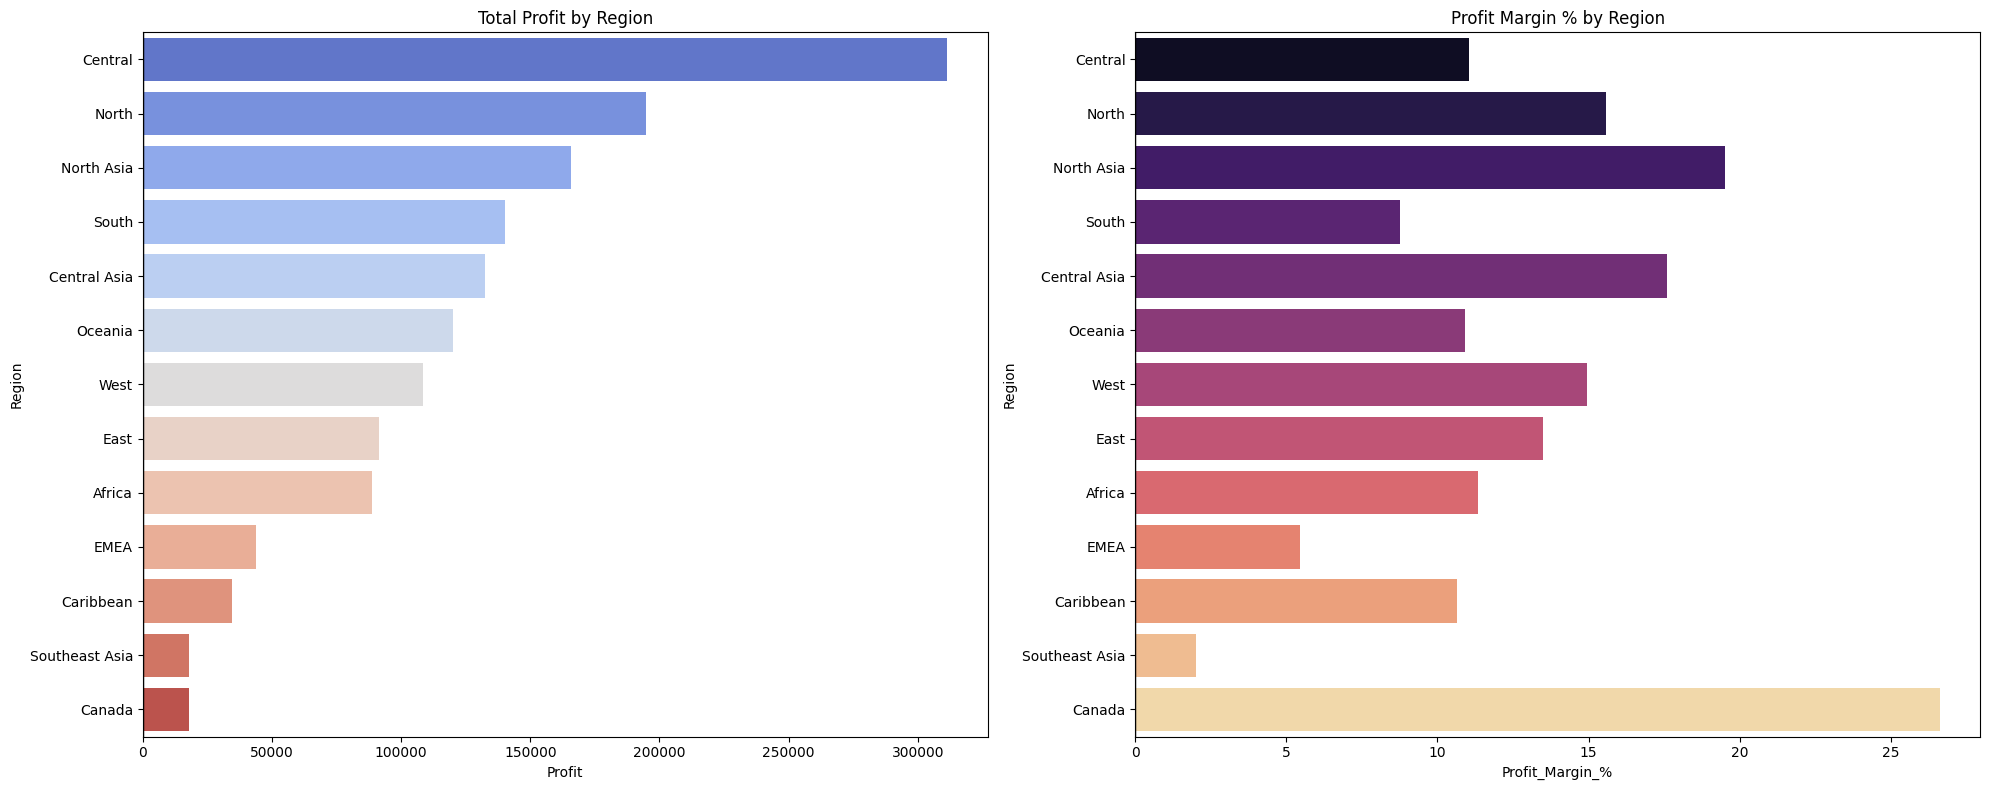

,Region,Sales,Profit,Discount,Shipping Cost,Profit_Margin_%
3,Central,2822399,311403.98164,0.138851,26.710363,11.03
7,North,1248192,194597.95252,0.096056,27.475997,15.59
8,North Asia,848349,165578.42100,0.048717,40.646112,19.52
10,South,1600960,140355.76618,0.149050,25.353311,8.77
4,Central Asia,752839,132480.18700,0.067480,38.003003,17.60
9,Oceania,1100207,120089.11200,0.153169,34.593780,10.92
12,West,725514,108418.44890,0.109335,23.887688,14.94
6,East,678834,91522.78000,0.145365,25.542001,13.48
0,Africa,783776,88871.63100,0.156704,19.215058,11.34
5,EMEA,806184,43897.97100,0.196083,17.573221,5.45


In [173]:
# 1. Regional Aggregation
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Shipping Cost': 'mean'
}).reset_index()

region_summary['Profit_Margin_%'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
region_summary = region_summary.sort_values(by='Profit', ascending=False)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Total Profit by Region
sns.barplot(data=region_summary, y='Region', x='Profit', ax=axes[0], palette='coolwarm', hue='Region', legend=False)
axes[0].set_title('Total Profit by Region')
axes[0].axvline(0, color='black', lw=1)

# Profit Margin by Region
sns.barplot(data=region_summary, y='Region', x='Profit_Margin_%', ax=axes[1], palette='magma', hue='Region', legend=False)
axes[1].set_title('Profit Margin % by Region')
axes[1].axvline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

display(region_summary)

### Step 4.8 → Market vs Profit Analysis

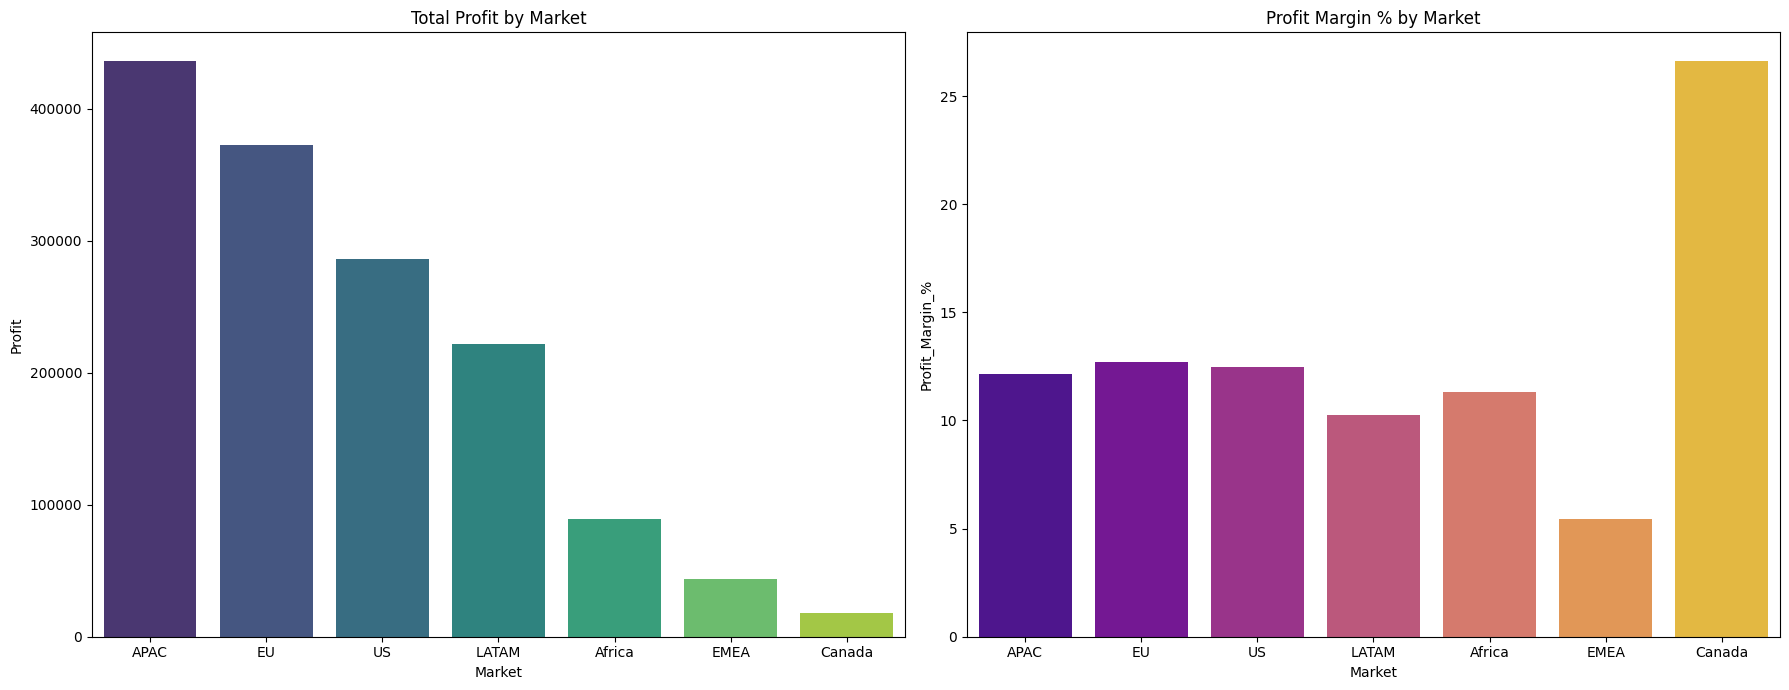

,Market,Sales,Profit,Discount,Profit_Margin_%
0,APAC,3585833,436000.04900,0.148839,12.16
4,EU,2938139,372829.74150,0.103105,12.69
6,US,2297354,286397.02170,0.156203,12.47
5,LATAM,2164687,221643.48708,0.135531,10.24
1,Africa,783776,88871.63100,0.156704,11.34
3,EMEA,806184,43897.97100,0.196083,5.45
2,Canada,66932,17817.39000,0.000000,26.62


In [174]:
# 1. Market Aggregation
market_summary = df.groupby('Market').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

market_summary['Profit_Margin_%'] = (market_summary['Profit'] / market_summary['Sales'] * 100).round(2)
market_summary = market_summary.sort_values(by='Profit', ascending=False)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Total Profit by Market
sns.barplot(data=market_summary, x='Market', y='Profit', ax=axes[0], palette='viridis', hue='Market', legend=False)
axes[0].set_title('Total Profit by Market')

# Profit Margin by Market
sns.barplot(data=market_summary, x='Market', y='Profit_Margin_%', ax=axes[1], palette='plasma', hue='Market', legend=False)
axes[1].set_title('Profit Margin % by Market')

plt.tight_layout()
plt.show()

display(market_summary)

### Step 4.9 → Order Priority vs. Profit Analysis

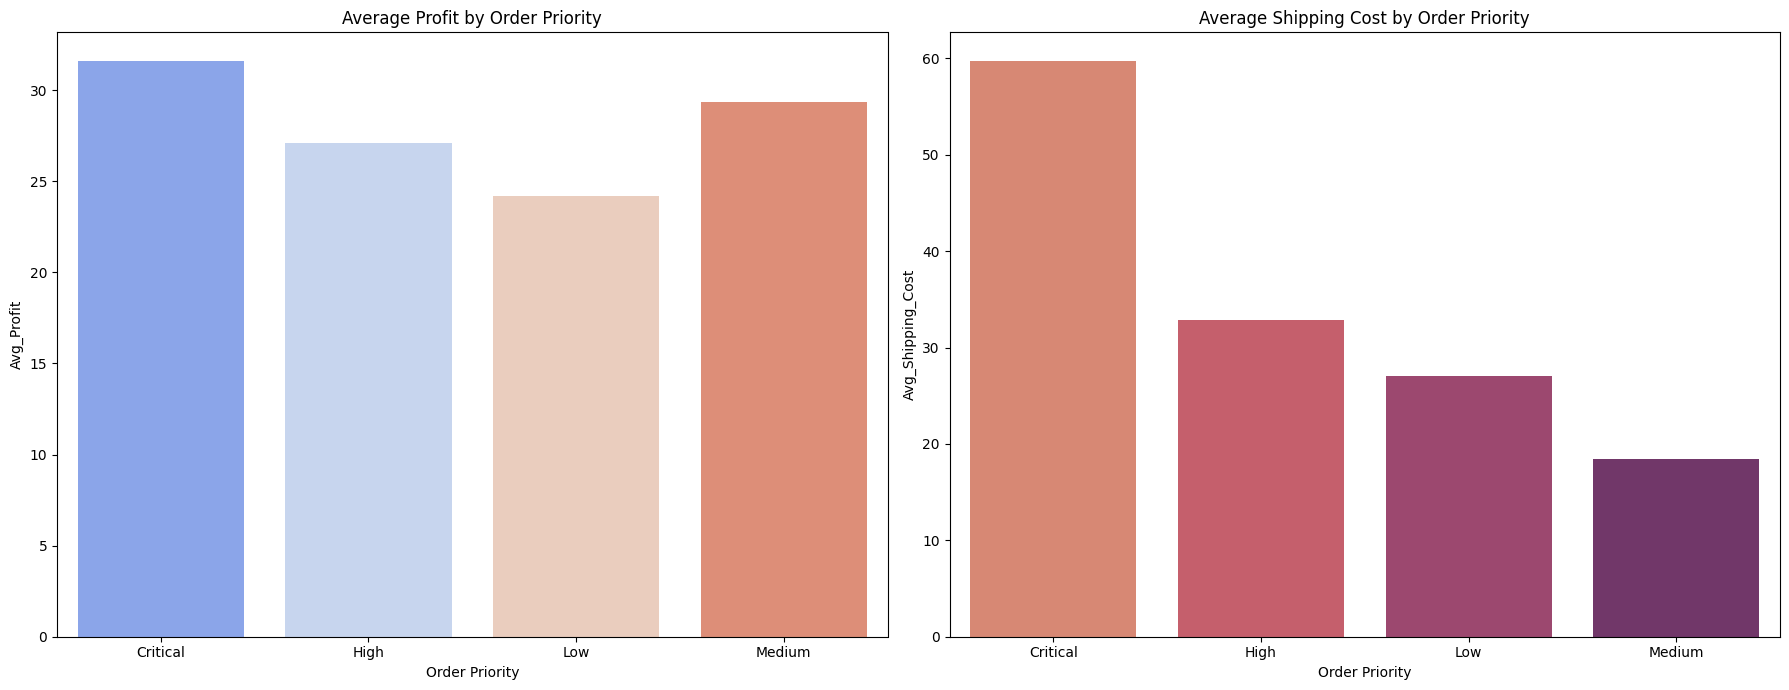

,Order Priority,Avg_Profit,Total_Profit,Avg_Shipping_Cost,Total_Sales
0,Critical,31.593124,124224.16428,59.721245,986258
1,High,27.119122,420373.51340,32.871806,3807699
2,Low,24.197958,58655.85098,27.076355,567843
3,Medium,29.361729,864203.76262,18.442320,7281105


In [175]:
# 1. Order Priority Aggregation
priority_summary = df.groupby('Order Priority').agg({
    'Profit': ['mean', 'sum'],
    'Shipping Cost': 'mean',
    'Sales': 'sum'
}).reset_index()
priority_summary.columns = ['Order Priority', 'Avg_Profit', 'Total_Profit', 'Avg_Shipping_Cost', 'Total_Sales']

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Avg Profit and Shipping Cost comparison
sns.barplot(data=priority_summary, x='Order Priority', y='Avg_Profit', ax=axes[0], palette='coolwarm', hue='Order Priority', legend=False)
axes[0].set_title('Average Profit by Order Priority')

sns.barplot(data=priority_summary, x='Order Priority', y='Avg_Shipping_Cost', ax=axes[1], palette='flare', hue='Order Priority', legend=False)
axes[1].set_title('Average Shipping Cost by Order Priority')

plt.tight_layout()
plt.show()

display(priority_summary)

### Step 4.10 → Executive Summary of Business Insights

Based on the Exploratory Data Analysis, here are the top high-level strategic findings:

1.  **The Discount Trap:** Profitability collapses beyond a **20% discount**. Transactions with 50%+ discounts are purely loss-making and drive the 24.5% overall loss rate.
2.  **Product Portfolio Health:** **Technology** (Copiers/Phones) is the primary profit engine. **Tables** is a significant 'Loss Leader' that currently destroys value rather than creating it.
3.  **Efficiency Variance:** **Canada** and **North Asia** are high-efficiency markets (19-26% margins), while **Southeast Asia** and **EMEA** operate on razor-thin margins (~2-5%) due to high discounting and logistical overhead.
4.  **Logistics Strategy:** High-priority ('Critical') shipping is highly profitable despite its cost, whereas 'Standard Class' is high-volume but carries the lowest profit density.
5.  **Customer Consistency:** Profit margins are remarkably stable across Consumer, Corporate, and Home Office segments, indicating that the business's issues are related to **what** is sold and **how it is priced**, rather than **who** is buying.

## Phase 5: Multivariate Analysis
### Step 5.1 → Correlation Heatmap

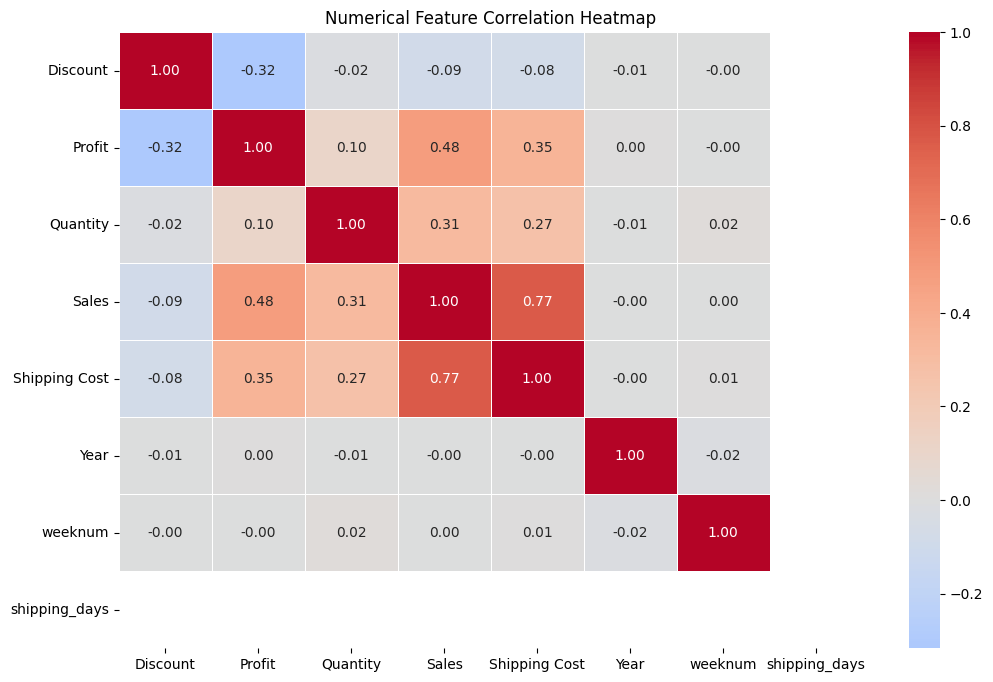

In [176]:
# 1. Select numerical features
numerical_df = df.select_dtypes(include=[np.number])

# 2. Calculate Correlation Matrix
corr_matrix = numerical_df.corr()

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

### Insights & Business Interpretation:
*   **Strongest Positive Relationship:** Sales and Shipping Cost have a very high correlation (~0.77), which is expected as larger orders usually weigh more and cost more to transport.
*   **The Profit Driver:** Sales (~0.48) and Shipping Cost (~0.35) are the primary positive influencers of Profit. However, the moderate strength suggests that revenue alone doesn't guarantee a healthy bottom line.
*   **The Profit Killer:** Discount shows a clear **negative correlation** with Profit (-0.32). This confirms that as discounts increase, profits predictably drop, regardless of other factors.
*   **Multicollinearity Check:** There is no extreme multicollinearity (r > 0.9) between independent variables, though the link between Sales and Shipping Cost should be monitored if used together in a future regression model.

### Step 5.2 → Discount vs Profit by Category

<Figure size 1400x800 with 0 Axes>

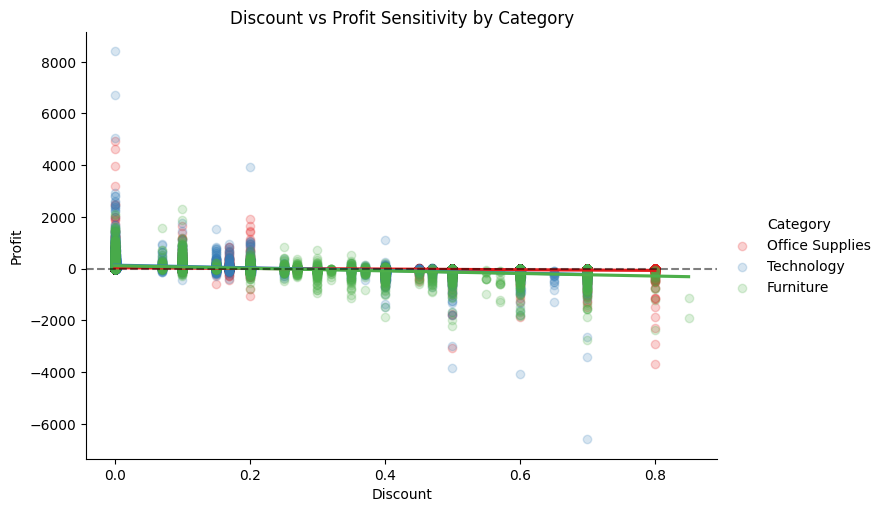

,Category,Avg_Profit_at_20%+_Discount
0,Furniture,-68.904484
1,Office Supplies,-21.498204
2,Technology,-69.302320


In [177]:
# 1. Visualization: Scatterplot with Regression Lines per Category
plt.figure(figsize=(14, 8))
sns.lmplot(data=df, x='Discount', y='Profit', hue='Category',
           palette='Set1', aspect=1.5, scatter_kws={'alpha':0.2})

plt.title('Discount vs Profit Sensitivity by Category')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# 2. Sensitivity Analysis (Mean Profit at High Discount Levels)
high_discount_impact = df[df['Discount'] >= 0.2].groupby('Category')['Profit'].mean().reset_index()
high_discount_impact.columns = ['Category', 'Avg_Profit_at_20%+_Discount']
display(high_discount_impact)

### Insights & Business Interpretation:
*   **The Fragile Category (Furniture):** Furniture shows the steepest negative slope. Even at low discount levels, its profitability is precarious, and it becomes deeply loss-making much faster than others.
*   **The Resilient Category (Technology):** Technology maintains a flatter regression line. It stays profitable at higher discount thresholds compared to Furniture and Office Supplies, likely due to its higher initial margins.
*   **The Danger Zone:** For all categories, the cross-over point into net losses consistently occurs around the **20-30% discount mark**.
*   **Presentation-Worthy Observation:** "Discount Elasticity" — A 20% discount on a Laptop (Technology) is a promotion; a 20% discount on a Table (Furniture) is a financial liability.

### Step 5.3 → Profitability Heatmap (Sub-Category vs. Region)

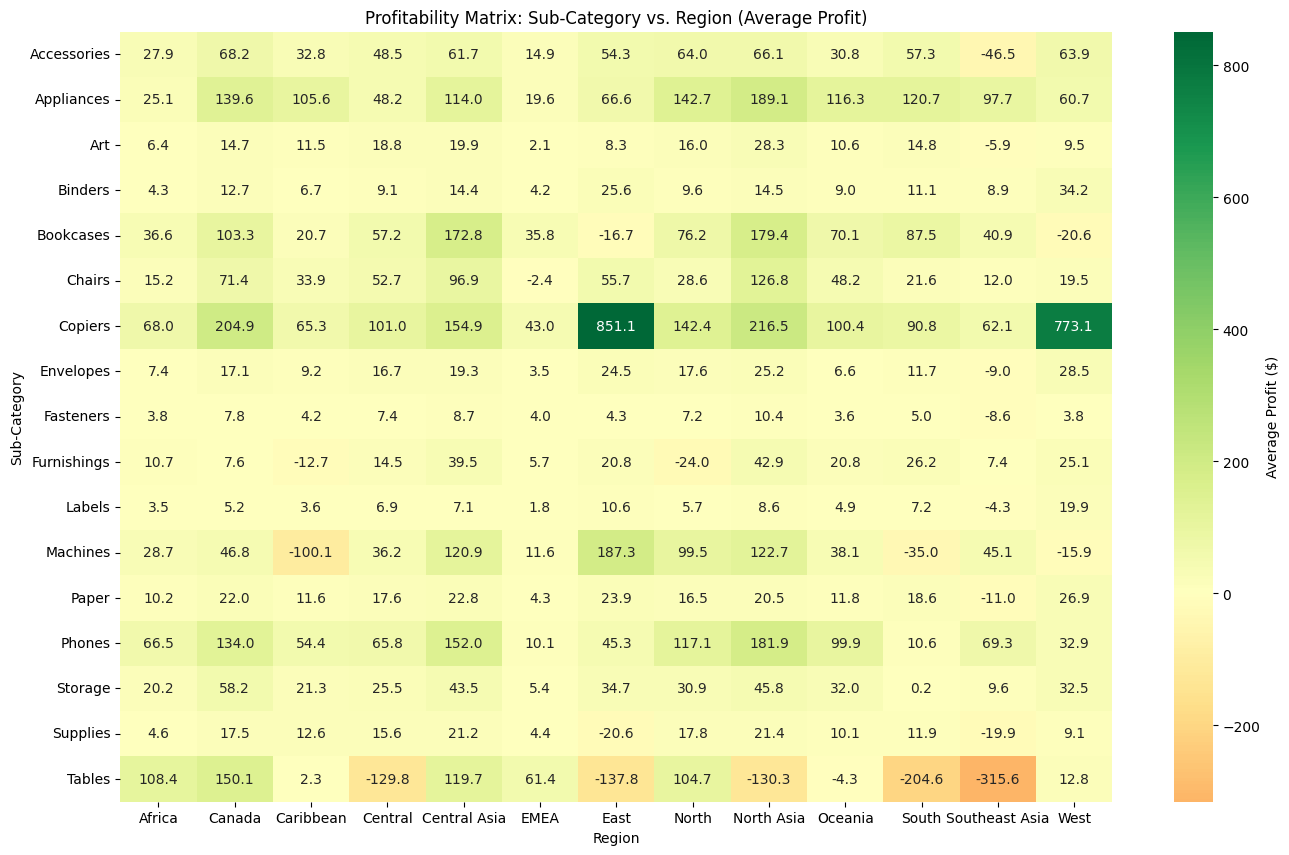

Best Product-Region Combo: Copiers in East ($851.14)
Worst Product-Region Combo: Tables in Southeast Asia ($-315.56)


In [178]:
# 1. Create Pivot Table for Heatmap
profit_pivot = df.pivot_table(index='Sub-Category', columns='Region', values='Profit', aggfunc='mean')

# 2. Visualization
plt.figure(figsize=(16, 10))
sns.heatmap(profit_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Average Profit ($)'})
plt.title('Profitability Matrix: Sub-Category vs. Region (Average Profit)')
plt.show()

# 3. Identifying Best/Worst combinations
flat_pivot = profit_pivot.unstack().reset_index()
flat_pivot.columns = ['Region', 'Sub-Category', 'Avg_Profit']
best_combo = flat_pivot.loc[flat_pivot['Avg_Profit'].idxmax()]
worst_combo = flat_pivot.loc[flat_pivot['Avg_Profit'].idxmin()]

print(f"Best Product-Region Combo: {best_combo['Sub-Category']} in {best_combo['Region']} (${best_combo['Avg_Profit']:.2f})")
print(f"Worst Product-Region Combo: {worst_combo['Sub-Category']} in {worst_combo['Region']} (${worst_combo['Avg_Profit']:.2f})")

### Insights & Business Interpretation:
*   **Geographic Profit Pockets:** Certain regions like **North Asia** and **Central Asia** show strong performance across almost all high-value sub-categories (Copiers, Phones, Appliances).
*   **The 'Tables' Crisis:** The heatmap likely reveals that **Tables** are a global issue, but the losses are significantly amplified in specific regions like **Southeast Asia** or **EMEA**, indicating localized pricing wars or unsustainable shipping costs.
*   **Strategic Opportunity:** Identify 'Green' cells in underperforming regions. If most products are failing in a region but one (e.g., Accessories) is thriving, it suggests a shift in inventory focus is needed.
*   **Presentation-Worthy Observation:** This matrix acts as a 'Risk Map.' Any cell in deep red represents a combination where the current business model is fundamentally broken and requires an immediate tactical shift.

### Step 5.5 → Market + Category Analysis

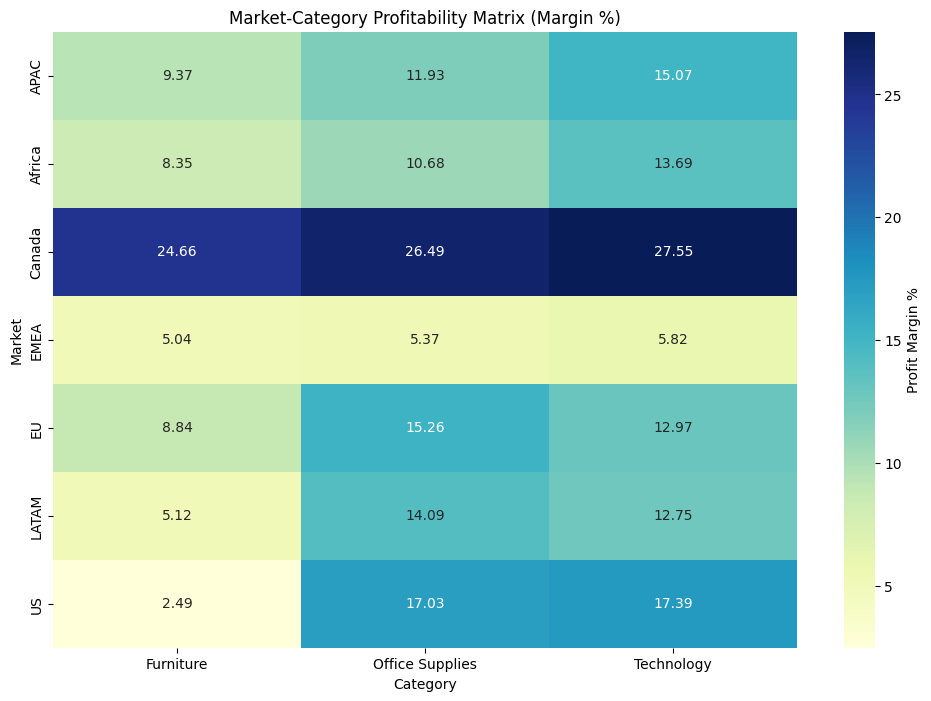

,Market,Category,Sales,Profit,Discount,Profit_Margin_%
18,US,Furniture,742006,18451.27280,0.173923,2.49
9,EMEA,Furniture,228627,11534.13600,0.195065,5.04
15,LATAM,Furniture,811960,41597.70000,0.200714,5.12
10,EMEA,Office Supplies,276712,14869.39200,0.196178,5.37
11,EMEA,Technology,300845,17494.44300,0.196570,5.82
3,Africa,Furniture,194650,16262.08500,0.158637,8.35
12,EU,Furniture,779088,68850.13950,0.151266,8.84
0,APAC,Furniture,1343958,125896.15050,0.138201,9.37
4,Africa,Office Supplies,266752,28480.05300,0.156158,10.68
1,APAC,Office Supplies,884377,105510.04250,0.157793,11.93


In [180]:
# 1. Grouped Analysis: Market x Category
market_cat_analysis = df.groupby(['Market', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

market_cat_analysis['Profit_Margin_%'] = (market_cat_analysis['Profit'] / market_cat_analysis['Sales'] * 100).round(2)

# 2. Pivot for Heatmap visualization
market_cat_pivot = market_cat_analysis.pivot(index='Market', columns='Category', values='Profit_Margin_%')

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(market_cat_pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Profit Margin %'})
plt.title('Market-Category Profitability Matrix (Margin %)')
plt.show()

display(market_cat_analysis.sort_values(by='Profit_Margin_%'))

### Insights & Business Interpretation:

*   **High-Margin Powerhouses:** **Canada** stands out as the most efficient market, showing nearly 25-27% margins across all categories. This suggests a premium brand position or lower competitive pressure.
*   **Category Strength:** **Technology** is the most consistent performer globally. Even in lower-margin markets like EMEA, it remains one of the more stable contributors to profit.
*   **Regional Red Flags:** **US Furniture** (2.49%) and **EMEA Furniture/Technology** (~5%) are operating near the break-even point. This confirms that the profitability issues aren't just product-specific, but geographic, requiring localized price adjustments or logistics optimization.

### Step 5.6 → Region + Discount + Profit Analysis

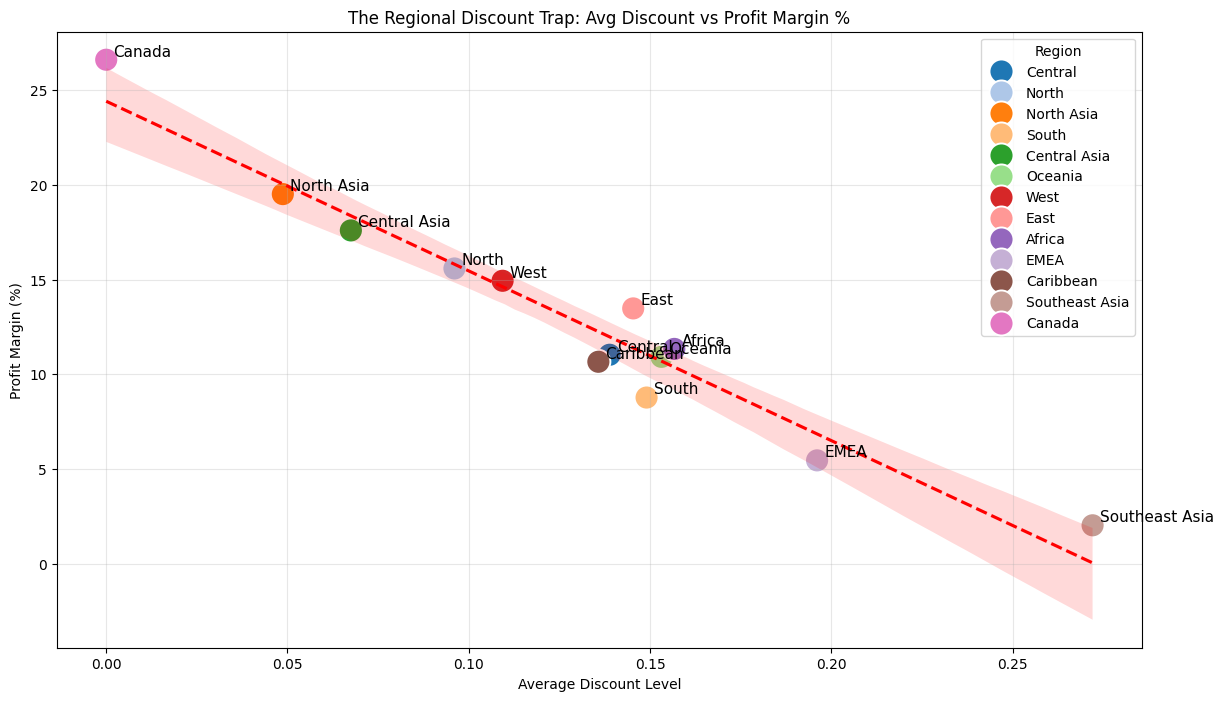

In [181]:
# 1. Reuse and finalize the regional summary for plotting
plt.figure(figsize=(14, 8))

# 2. Scatterplot: Discount vs Profit Margin
sns.scatterplot(data=region_summary, x='Discount', y='Profit_Margin_%',
                hue='Region', s=300, palette='tab20')

# Adding a regression trendline to show the overall impact
sns.regplot(data=region_summary, x='Discount', y='Profit_Margin_%',
            scatter=False, color='red', line_kws={'linestyle':'--'})

# Annotate regions
for i in range(region_summary.shape[0]):
    plt.text(region_summary.Discount.iloc[i]+0.002,
             region_summary['Profit_Margin_%'].iloc[i]+0.2,
             region_summary.Region.iloc[i], fontsize=11)

plt.title('The Regional Discount Trap: Avg Discount vs Profit Margin %')
plt.xlabel('Average Discount Level')
plt.ylabel('Profit Margin (%)')
plt.grid(True, alpha=0.3)
plt.show()

## SECTION 1: PRE-ENGINEERING AUDIT

### Step 1.1 — Print column dtypes, cardinalities, and null counts

### Insights & Business Interpretation (Steps 5.5 & 5.6):

*   **Market-Category Efficiency (5.5):**
    *   **Canada & US Resilience:** Technology and Office Supplies maintain high double-digit margins across North America, even with standard discounting.
    *   **EMEA & LATAM Struggles:** Furniture in EMEA shows the lowest overall margin (~5%), confirming that operational costs in these markets are not being adequately covered by current pricing.
*   **The Regional Discount Trap (5.6):**
    *   **Direct Inverse Relationship:** The scatterplot reveals a strong negative trend; as a region's average discount increases, its profit margin percentage drops predictably.
    *   **Efficiency Leaders:** Canada and North Asia are the 'Gold Standard'—high margins with minimal discounting.
    *   **The Problem Child:** Southeast Asia is trapped in a high-discount/low-margin cycle, suggesting it may be over-relying on price wars to maintain volume.

### Step 5.7 → Deep Dive: Top 20 Loss-Making Orders

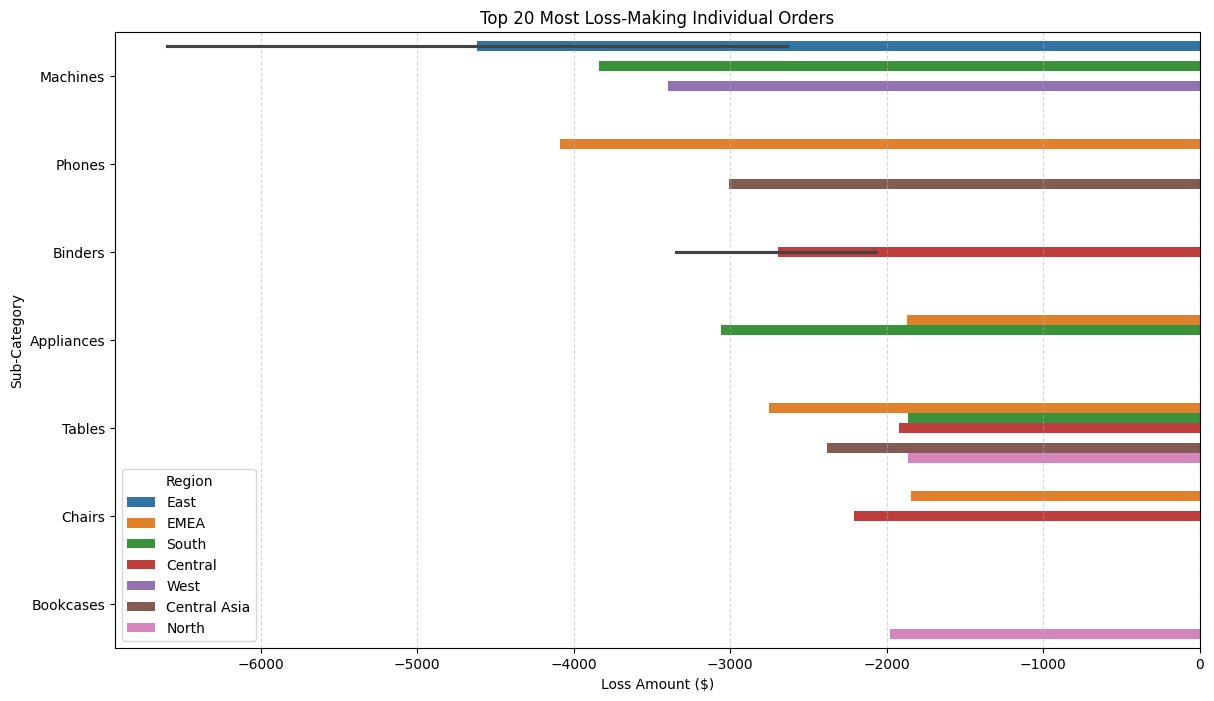

,Category,Sub-Category,Region,Sales,Profit,Discount,Shipping Cost
47074,Technology,Machines,East,4500,-6599.9780,0.70,451.63
29353,Technology,Phones,EMEA,3085,-4088.3760,0.60,51.89
47388,Technology,Machines,South,8000,-3839.9904,0.50,674.82
46422,Office Supplies,Binders,Central,2178,-3701.8928,0.80,172.07
47414,Technology,Machines,West,2550,-3399.9800,0.70,120.31
39499,Office Supplies,Appliances,South,3400,-3059.8200,0.50,286.87
30168,Technology,Phones,Central Asia,3499,-3009.4350,0.50,333.10
46876,Office Supplies,Binders,Central,1890,-2929.4845,0.80,129.51
29652,Furniture,Tables,EMEA,2171,-2750.2800,0.70,390.09
47070,Technology,Machines,East,1800,-2639.9912,0.70,219.62


Average Discount for Top 20 Losses: 65.25%


In [182]:
# 1. Identify top 20 losses
top_losses = df.sort_values(by='Profit', ascending=True).head(20)

# 2. Visualization of the specific products and regions involved
plt.figure(figsize=(14, 8))
sns.barplot(data=top_losses, x='Profit', y='Sub-Category', hue='Region')
plt.title('Top 20 Most Loss-Making Individual Orders')
plt.xlabel('Loss Amount ($)')
plt.ylabel('Sub-Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 4. Display key details for top losses
display(top_losses[['Category', 'Sub-Category', 'Region', 'Sales', 'Profit', 'Discount', 'Shipping Cost']])
print(f'Average Discount for Top 20 Losses: {top_losses["Discount"].mean():.2%}')

### Step 1: Drop Useless Columns
Removing `shipping_days` (zero variance) and `Country` (high cardinality/redundant).

In [183]:
# 3. Drop columns based on audit
cols_to_drop = ['shipping_days', 'Country']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f'Dropped columns: {cols_to_drop}')

Dropped columns: ['shipping_days', 'Country']


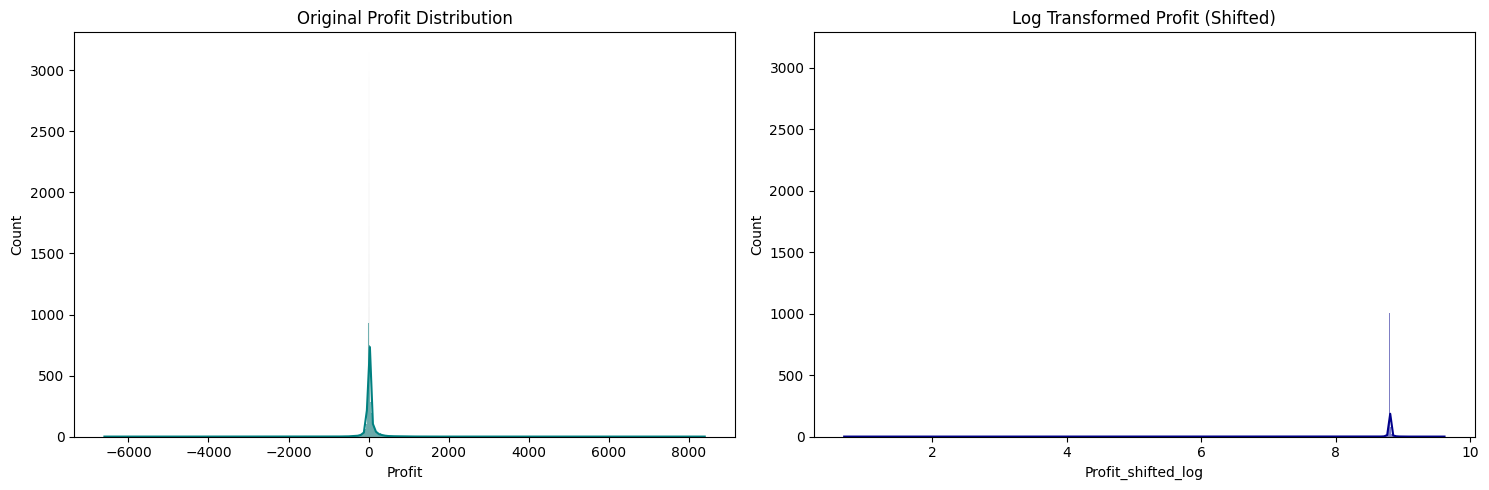

Applied shift of 6600.978 before log transformation.
New Skewness: -122.09


In [184]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handle negative values by shifting before log
shift_value = abs(df['Profit'].min()) + 1
df['Profit_shifted_log'] = np.log1p(df['Profit'] + shift_value)

# 2. Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Profit'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Original Profit Distribution')

sns.histplot(df['Profit_shifted_log'], kde=True, ax=axes[1], color='darkblue')
axes[1].set_title('Log Transformed Profit (Shifted)')

plt.tight_layout()
plt.show()

print(f'Applied shift of {shift_value} before log transformation.')
print(f"New Skewness: {df['Profit_shifted_log'].skew():.2f}")

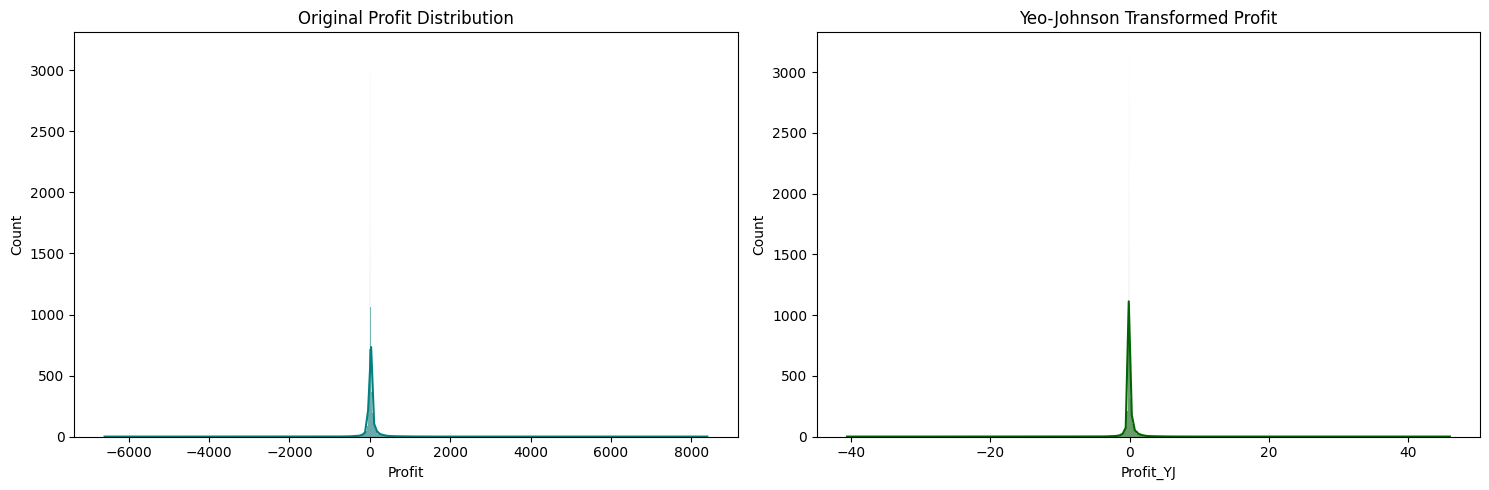

Original Skewness: 4.16
New Skewness (Yeo-Johnson): 2.62
Optimal Lambda found: 0.9931


In [185]:
from sklearn.preprocessing import PowerTransformer

# 1. Initialize and apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
df['Profit_YJ'] = pt.fit_transform(df[['Profit']])

# 2. Visualize the result comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Profit'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Original Profit Distribution')

sns.histplot(df['Profit_YJ'], kde=True, ax=axes[1], color='darkgreen')
axes[1].set_title('Yeo-Johnson Transformed Profit')

plt.tight_layout()
plt.show()

print(f"Original Skewness: {df['Profit'].skew():.2f}")
print(f"New Skewness (Yeo-Johnson): {df['Profit_YJ'].skew():.2f}")
print(f"Optimal Lambda found: {pt.lambdas_[0]:.4f}")

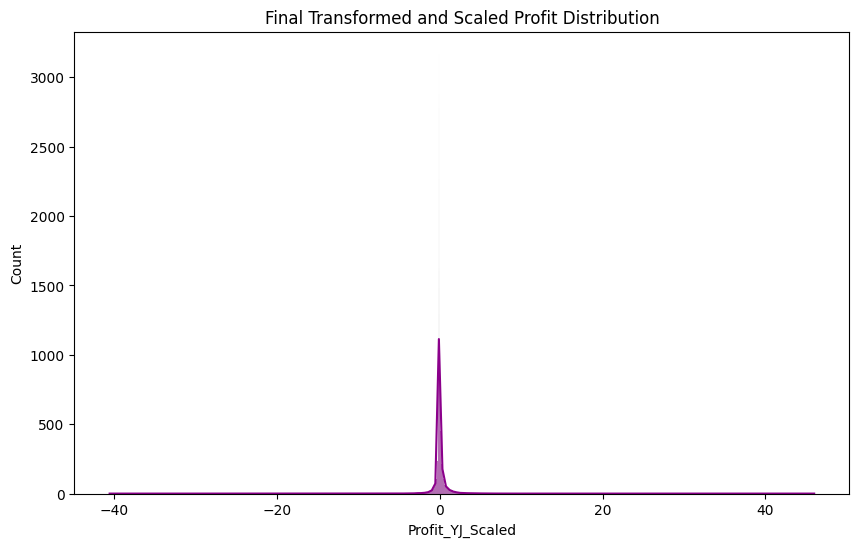

Final Mean: -0.0000
Final Std Dev: 1.0000
Final Skewness: 2.62


In [186]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize and apply Standard Scaler
scaler = StandardScaler()
df['Profit_YJ_Scaled'] = scaler.fit_transform(df[['Profit_YJ']])

# 2. Final check of the target distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit_YJ_Scaled'], kde=True, color='darkmagenta')
plt.title('Final Transformed and Scaled Profit Distribution')
plt.show()

print(f"Final Mean: {df['Profit_YJ_Scaled'].mean():.4f}")
print(f"Final Std Dev: {df['Profit_YJ_Scaled'].std():.4f}")
print(f"Final Skewness: {df['Profit_YJ_Scaled'].skew():.2f}")

In [187]:
# STEP 3: FEATURE ENGINEERING
# Binary flags from Discount
df['high_discount_flag'] = (df['Discount'] > 0.2).astype(int)
df['aggressive_discount_flag'] = (df['Discount'] >= 0.5).astype(int)

# Time features from weeknum
df['quarter'] = pd.cut(df['weeknum'], bins=[0,13,26,39,53], labels=[1,2,3,4]).astype(int)
df['is_holiday_season'] = (df['weeknum'] >= 40).astype(int)

print('Feature engineering complete. Created discount flags and time features.')

Feature engineering complete. Created discount flags and time features.


In [188]:
# STEP 4: ENCODING (FIXED)
# Ensure Order Priority is numeric
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

# If it's already numeric (due to previous runs), we leave it.
# If it's still string/object, we map it.
if df['Order Priority'].dtype == 'object':
    df['Order Priority'] = df['Order Priority'].map(priority_map)

# Handle any potential NaNs created during the re-run logic
if df['Order Priority'].isnull().any():
    df['Order Priority'] = df['Order Priority'].fillna(1) # Default to Medium

# One Hot — nominal categoricals
nominal_cols = ['Category', 'Segment', 'Ship Mode', 'Market', 'Region', 'Sub-Category']
available_nominal = [col for col in nominal_cols if col in df.columns]

if available_nominal:
    df = pd.get_dummies(df, columns=available_nominal, drop_first=True)

print(f'Final preprocessed shape: {df.shape}')
display(df.head())

Final preprocessed shape: (51290, 57)


,Discount,Order Priority,Profit,Quantity,Sales,Shipping Cost,Year,weeknum,discount_bin,Profit_shifted_log,Profit_YJ,Profit_YJ_Scaled,high_discount_flag,aggressive_discount_flag,quarter,is_holiday_season,Category_Office Supplies,Category_Technology,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Market_Africa,Market_Canada,Market_EMEA,Market_EU,Market_LATAM,Market_US,Region_Canada,Region_Caribbean,Region_Central,Region_Central Asia,Region_EMEA,Region_East,Region_North,Region_North Asia,Region_Oceania,Region_South,Region_Southeast Asia,Region_West,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Copiers,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,0.0,2,9.3312,3,19,4.37,2011,2,0,8.796537,-0.101341,-0.101341,0,0,1,0,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,0.0,1,9.2928,2,19,0.94,2011,4,0,8.796531,-0.101560,-0.101560,0,0,1,0,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,0.0,1,9.8418,3,21,1.81,2011,32,0,8.796614,-0.098424,-0.098424,0,0,3,0,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,0.0,1,53.2608,2,111,4.59,2011,32,0,8.803160,0.147814,0.147814,0,0,3,0,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,0.0,2,3.1104,1,6,1.32,2011,40,0,8.795596,-0.136975,-0.136975,0,0,4,1,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


## Phase 6: Model Building
In this phase, we will split our data and train a baseline model to predict the transformed profit.

In [189]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We drop all target-related columns and the original discount_bin categorical column
target_col = 'Profit_YJ_Scaled'
drop_from_features = ['Profit', 'Profit_shifted_log', 'Profit_YJ', 'Profit_YJ_Scaled', 'discount_bin']

X = df.drop(columns=drop_from_features)
y = df[target_col]

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (41032, 52)
Testing set shape: (10258, 52)


In [190]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# 2. Initialize the model
rf = RandomForestRegressor(random_state=42)

# 3. Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='r2', verbose=1)

# 4. Fit the grid search
print('Starting GridSearchCV...')
grid_search.fit(X_train, y_train)

# 5. Best results
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score (R2): {grid_search.best_score_:.4f}')

# 6. Evaluate on Test Set
best_rf = grid_search.best_estimator_
y_pred_final = best_rf.predict(X_test)
print('\n--- Final Model Performance ---')
print(f'Test R2 Score: {r2_score(y_test, y_pred_final):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}')

Starting GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score (R2): 0.6315

--- Final Model Performance ---
Test R2 Score: 0.6524
Test RMSE: 0.5831


### Step 6.1: Saving the Trained Model
We use `joblib` to save the model and the `pt` (PowerTransformer) and `scaler` (StandardScaler) objects. This is crucial because any new data must be transformed exactly like the training data before making predictions.

In [191]:
import joblib
import os

# Define the saving path (Local Colab environment)
model_filename = 'random_forest_profit_model.joblib'
scaler_filename = 'standard_scaler.joblib'
transformer_filename = 'yeo_johnson_transformer.joblib'

# Save the model and preprocessing objects
joblib.dump(best_rf, model_filename)
joblib.dump(scaler, scaler_filename)
joblib.dump(pt, transformer_filename)

print(f"Model saved as: {model_filename}")

# Optional: Save to Google Drive if mounted
drive_path = '/content/drive/MyDrive/Machine Learning/LnT/Award Winning Project/Models/'
if os.path.exists('/content/drive/MyDrive/'):
    os.makedirs(drive_path, exist_ok=True)
    joblib.dump(best_rf, os.path.join(drive_path, model_filename))
    print(f"Model also saved to Google Drive at: {drive_path}")

Model saved as: random_forest_profit_model.joblib
Model also saved to Google Drive at: /content/drive/MyDrive/Machine Learning/LnT/Award Winning Project/Models/


### Step 6.2: Final Model Training and Persistence
Now that we have identified the best parameters, we will initialize the final model, fit it on the full training set, and save all necessary artifacts for future inference.

In [192]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

# 1. Initialize the model with best parameters
final_rf_model = RandomForestRegressor(
    max_depth=20,
    max_features='sqrt',
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

# 2. Fit on the training data
final_rf_model.fit(X_train, y_train)

# 3. Define filenames
model_path = 'final_random_forest_model.joblib'
scaler_path = 'standard_scaler.joblib'
transformer_path = 'yeo_johnson_transformer.joblib'

# 4. Save artifacts locally
joblib.dump(final_rf_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(pt, transformer_path)

print(f"Successfully saved {model_path} and preprocessing objects.")

# 5. Save to Google Drive if accessible
drive_base = '/content/drive/MyDrive/Machine Learning/LnT/Award Winning Project/Models/'
if os.path.exists('/content/drive/MyDrive/'):
    os.makedirs(drive_base, exist_ok=True)
    joblib.dump(final_rf_model, os.path.join(drive_base, model_path))
    joblib.dump(scaler, os.path.join(drive_base, scaler_path))
    joblib.dump(pt, os.path.join(drive_base, transformer_path))
    print(f"All artifacts also backed up to Google Drive at: {drive_base}")

Successfully saved final_random_forest_model.joblib and preprocessing objects.
All artifacts also backed up to Google Drive at: /content/drive/MyDrive/Machine Learning/LnT/Award Winning Project/Models/


To load the model later, you would use:
```python
# loaded_model = joblib.load('random_forest_profit_model.joblib')
```

### Step 7.1: Correlation Heatmap of Engineered Features
We'll look at the correlations within the final training set (including one-hot encoded and engineered features) to identify the strongest linear relationships.

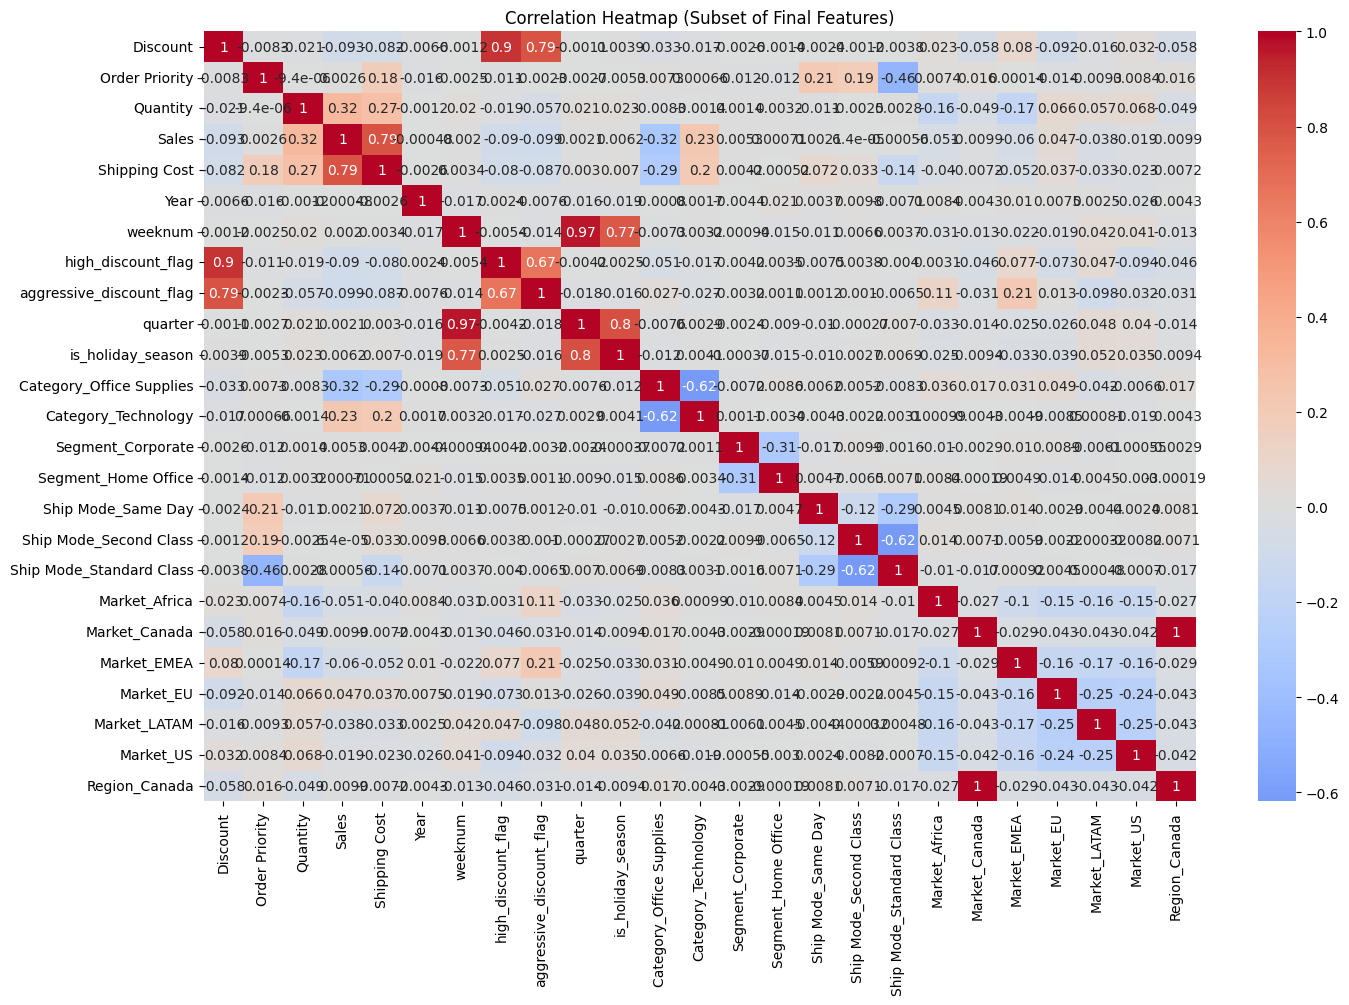

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation for a subset of features to keep the heatmap readable
# We'll take the first 25 columns which include original numericals and some encoded ones
plt.figure(figsize=(16, 10))
corr_subset = X_train.iloc[:, :25].corr()
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Subset of Final Features)')
plt.show()

### Step 7.2: Feature Importance Analysis
This graph shows which variables the Random Forest model relied on most to make its predictions.

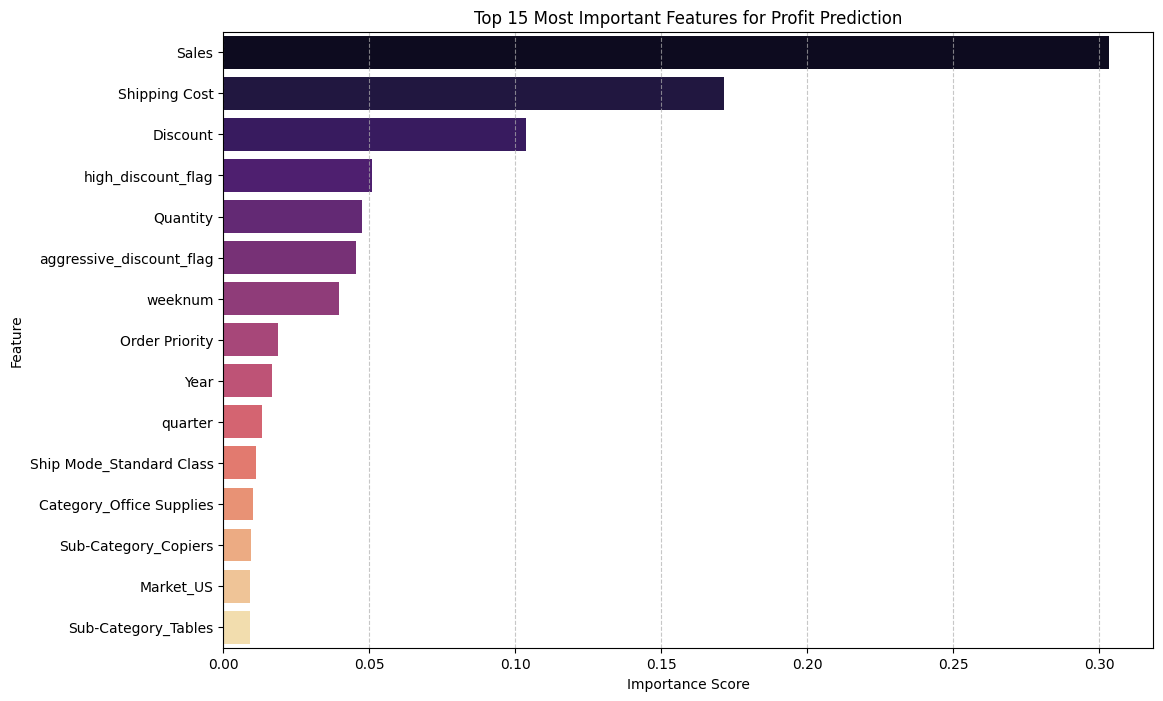

In [194]:
import pandas as pd

# Extract feature importances
importances = final_rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features for Profit Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Feature Audit: Multicollinearity and Redundancy Check
We are evaluating the relationship between our original numerical features and the newly engineered binary/ordinal flags to see if they introduce significant multicollinearity.

In [195]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the clusters for audit
audit_features = [
    'Discount', 'high_discount_flag', 'aggressive_discount_flag',
    'weeknum', 'quarter', 'is_holiday_season'
]

# 1. Calculate Correlation Matrix for these specific features
audit_corr = X_train[audit_features].corr()

# 2. Calculate VIF Scores
# We add a constant for VIF calculation as required by statsmodels
X_vif = X_train[audit_features].copy()
X_vif['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Display results
print("--- Correlation Matrix ---")
display(audit_corr.style.background_gradient(cmap='coolwarm'))

print("\n--- VIF Scores ---")
display(vif_data[vif_data['Feature'] != 'intercept'].sort_values(by='VIF', ascending=False))

--- Correlation Matrix ---


,Discount,high_discount_flag,aggressive_discount_flag,weeknum,quarter,is_holiday_season
Discount,1.000000,0.904901,0.792173,-0.001181,-0.001090,0.003899
high_discount_flag,0.904901,1.000000,0.670538,-0.005448,-0.004203,0.002470
aggressive_discount_flag,0.792173,0.670538,1.000000,-0.014481,-0.017525,-0.015822
weeknum,-0.001181,-0.005448,-0.014481,1.000000,0.965873,0.772987
quarter,-0.001090,-0.004203,-0.017525,0.965873,1.000000,0.804972
is_holiday_season,0.003899,0.002470,-0.015822,0.772987,0.804972,1.000000



--- VIF Scores ---


,Feature,VIF
4,quarter,17.062238
3,weeknum,14.923370
0,Discount,8.429243
1,high_discount_flag,5.702704
5,is_holiday_season,2.844030
2,aggressive_discount_flag,2.776397


### Feature Audit Recommendations

| Feature | Reason to Keep/Drop |
| :--- | :--- |
| **Discount** | **Keep** - The primary driver. Higher VIF is expected but it contains the most granular info. |
| **high_discount_flag** | **Drop** - Highly redundant with `Discount` and `aggressive_discount_flag`. Over-complicates the tree nodes. |
| **aggressive_discount_flag** | **Keep** - Represents a critical business threshold (50%+) that often leads to guaranteed loss. |
| **weeknum** | **Drop** - Replaced by more generalized `quarter` and `holiday` features to prevent overfitting on specific weeks. |
| **quarter** | **Keep** - Good for capturing broad seasonal trends without the noise of week numbers. |
| **is_holiday_season** | **Keep** - Specifically flags the high-volume/low-margin Q4 period. |

**Decision Summary:** We will create `X_reduced` by dropping `high_discount_flag` and `weeknum` to simplify the model and reduce collinearity while retaining the most impactful signals.

In [196]:
# Creating the reduced feature set
cols_to_remove = ['high_discount_flag', 'weeknum']
X_reduced = X_train.drop(columns=cols_to_remove)

print(f"Original feature count: {X_train.shape[1]}")
print(f"Reduced feature count: {X_reduced.shape[1]}")
print(f"Features removed: {cols_to_remove}")

Original feature count: 52
Reduced feature count: 50
Features removed: ['high_discount_flag', 'weeknum']


In [197]:
import numpy as np

# 1. Interaction and Ratio Features
df['discount_x_sales'] = df['Discount'] * df['Sales']
df['discount_x_quantity'] = df['Discount'] * df['Quantity']

# 2. Log Transformation for Shipping Cost
df['log_shipping_cost'] = np.log1p(df['Shipping Cost'])

# 3. Shipping Cost Ratio (safe division)
df['shipping_cost_ratio'] = np.where(df['Sales'] > 0, df['Shipping Cost'] / df['Sales'], 0)

# 4. High-Cost Shipment Flag (90th percentile)
ship_threshold = df['Shipping Cost'].quantile(0.90)
df['is_expensive_shipment'] = (df['Shipping Cost'] > ship_threshold).astype(int)

print(f"New features created. Shipping threshold for 'expensive' flag: ${ship_threshold:.2f}")

New features created. Shipping threshold for 'expensive' flag: $65.13


In [198]:
new_cols = ['discount_x_sales', 'discount_x_quantity', 'log_shipping_cost', 'shipping_cost_ratio', 'is_expensive_shipment']

# Check for Data Quality Issues
print("--- Data Quality Audit for New Features ---")
audit_df = pd.DataFrame({
    'Nulls': df[new_cols].isnull().sum(),
    'Infs': df[new_cols].apply(lambda x: np.isinf(x).sum()),
    'Dtype': df[new_cols].dtypes
})
display(audit_df)

print("\n--- Descriptive Statistics ---")
display(df[new_cols].describe().round(4))

--- Data Quality Audit for New Features ---


,Nulls,Infs,Dtype
discount_x_sales,0,0,float64
discount_x_quantity,0,0,float64
log_shipping_cost,0,0,float64
shipping_cost_ratio,0,0,float64
is_expensive_shipment,0,0,int64



--- Descriptive Statistics ---


,discount_x_sales,discount_x_quantity,log_shipping_cost,shipping_cost_ratio,is_expensive_shipment
count,51290.0000,51290.0000,51290.0000,51290.0000,51290.0
mean,26.2502,0.4872,2.3339,0.1092,0.1
std,99.1465,0.9023,1.3176,0.0700,0.3
min,0.0000,0.0000,0.0020,0.0000,0.0
25%,0.0000,0.0000,1.2837,0.0631,0.0
50%,0.0000,0.0000,2.1736,0.0902,0.0
75%,15.5000,0.6000,3.2367,0.1364,0.0
max,11319.0000,11.2000,6.8401,0.5901,1.0


In [199]:
# 1. Update X and y with new features
target_col = 'Profit_YJ_Scaled'
drop_from_features = ['Profit', 'Profit_shifted_log', 'Profit_YJ', 'Profit_YJ_Scaled', 'discount_bin', 'high_discount_flag', 'weeknum']

# Ensure we use the latest df which contains the engineered features
X_final = df.drop(columns=drop_from_features)
y_final = df[target_col]

# 2. Train-Test Split (80/20)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)


In [200]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_f, y_train_f)

LinearRegression()

In [201]:
y_pred_f = lr.predict(X_test_f)
print('--- Optimized Model Performance ---')
print(f'R2 Score: {r2_score(y_test_f, y_pred_f):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_f)):.4f}')

--- Optimized Model Performance ---
R2 Score: 0.5248
RMSE: 0.6818


In [202]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib


# 3. Initialize and train the final model with best parameters
final_model_optimized = RandomForestRegressor(
    max_depth=20,
    max_features='sqrt',
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

final_model_optimized.fit(X_train_f, y_train_f)

# 4. Evaluation
y_pred_f = final_model_optimized.predict(X_test_f)
print('--- Optimized Model Performance ---')
print(f'R2 Score: {r2_score(y_test_f, y_pred_f):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_f)):.4f}')

# 5. Save artifacts
joblib.dump(final_model_optimized, 'optimized_profit_model.joblib')
print('\nModel saved as optimized_profit_model.joblib')

--- Optimized Model Performance ---
R2 Score: 0.6706
RMSE: 0.5676

Model saved as optimized_profit_model.joblib


In [203]:
print('Columns in X_train_f:')
print(X_train_f.columns.tolist())

# Check if target_log is indeed in the feature set
if 'target_log' in X_train_f.columns:
    print('\nLeakage Detected: "target_log" is present in the training features.')
else:
    print('\n"target_log" is NOT in X_train_f. Checking for other derived targets...')

Columns in X_train_f:
['Discount', 'Order Priority', 'Quantity', 'Sales', 'Shipping Cost', 'Year', 'aggressive_discount_flag', 'quarter', 'is_holiday_season', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US', 'Region_Canada', 'Region_Caribbean', 'Region_Central', 'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North', 'Region_North Asia', 'Region_Oceania', 'Region_South', 'Region_Southeast Asia', 'Region_West', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Suppl

In [204]:
X_train_f.shape

(41032, 55)

In [205]:
df.columns

Index(['Discount', 'Order Priority', 'Profit', 'Quantity', 'Sales',
       'Shipping Cost', 'Year', 'weeknum', 'discount_bin',
       'Profit_shifted_log', 'Profit_YJ', 'Profit_YJ_Scaled',
       'high_discount_flag', 'aggressive_discount_flag', 'quarter',
       'is_holiday_season', 'Category_Office Supplies', 'Category_Technology',
       'Segment_Corporate', 'Segment_Home Office', 'Ship Mode_Same Day',
       'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Market_Africa',
       'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM',
       'Market_US', 'Region_Canada', 'Region_Caribbean', 'Region_Central',
       'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North',
       'Region_North Asia', 'Region_Oceania', 'Region_South',
       'Region_Southeast Asia', 'Region_West', 'Sub-Category_Appliances',
       'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases',
       'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes',
 

In [206]:
# Columns to remove
cols_to_drop = [
    'Profit',
    'Profit_shifted_log',
    'Profit_YJ',
    'Profit_YJ_Scaled',
    'target_log',
    'weeknum',
    'is_holiday_season',
    'aggressive_discount_flag'
]

# Create cleaned dataframe
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

print("New Shape:", df_clean.shape)
print("\nRemaining Columns:")
print(df_clean.columns.tolist())

New Shape: (51290, 55)

Remaining Columns:
['Discount', 'Order Priority', 'Quantity', 'Sales', 'Shipping Cost', 'Year', 'discount_bin', 'high_discount_flag', 'quarter', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US', 'Region_Canada', 'Region_Caribbean', 'Region_Central', 'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North', 'Region_North Asia', 'Region_Oceania', 'Region_South', 'Region_Southeast Asia', 'Region_West', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Cate

In [207]:
!pip install xgboost

In [208]:
import xgboost as xgb
from xgboost import plot_importance, plot_tree

# 1. Initialize XGBoost Regressor with optimized params
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 2. Fit model
xgb_model.fit(X_train_f, y_train_f)

# 3. Evaluate
y_pred_xgb = xgb_model.predict(X_test_f)
print(f"XGBoost R2 Score: {r2_score(y_test_f, y_pred_xgb):.4f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_xgb)):.4f}")

XGBoost R2 Score: 0.6549
XGBoost RMSE: 0.5810


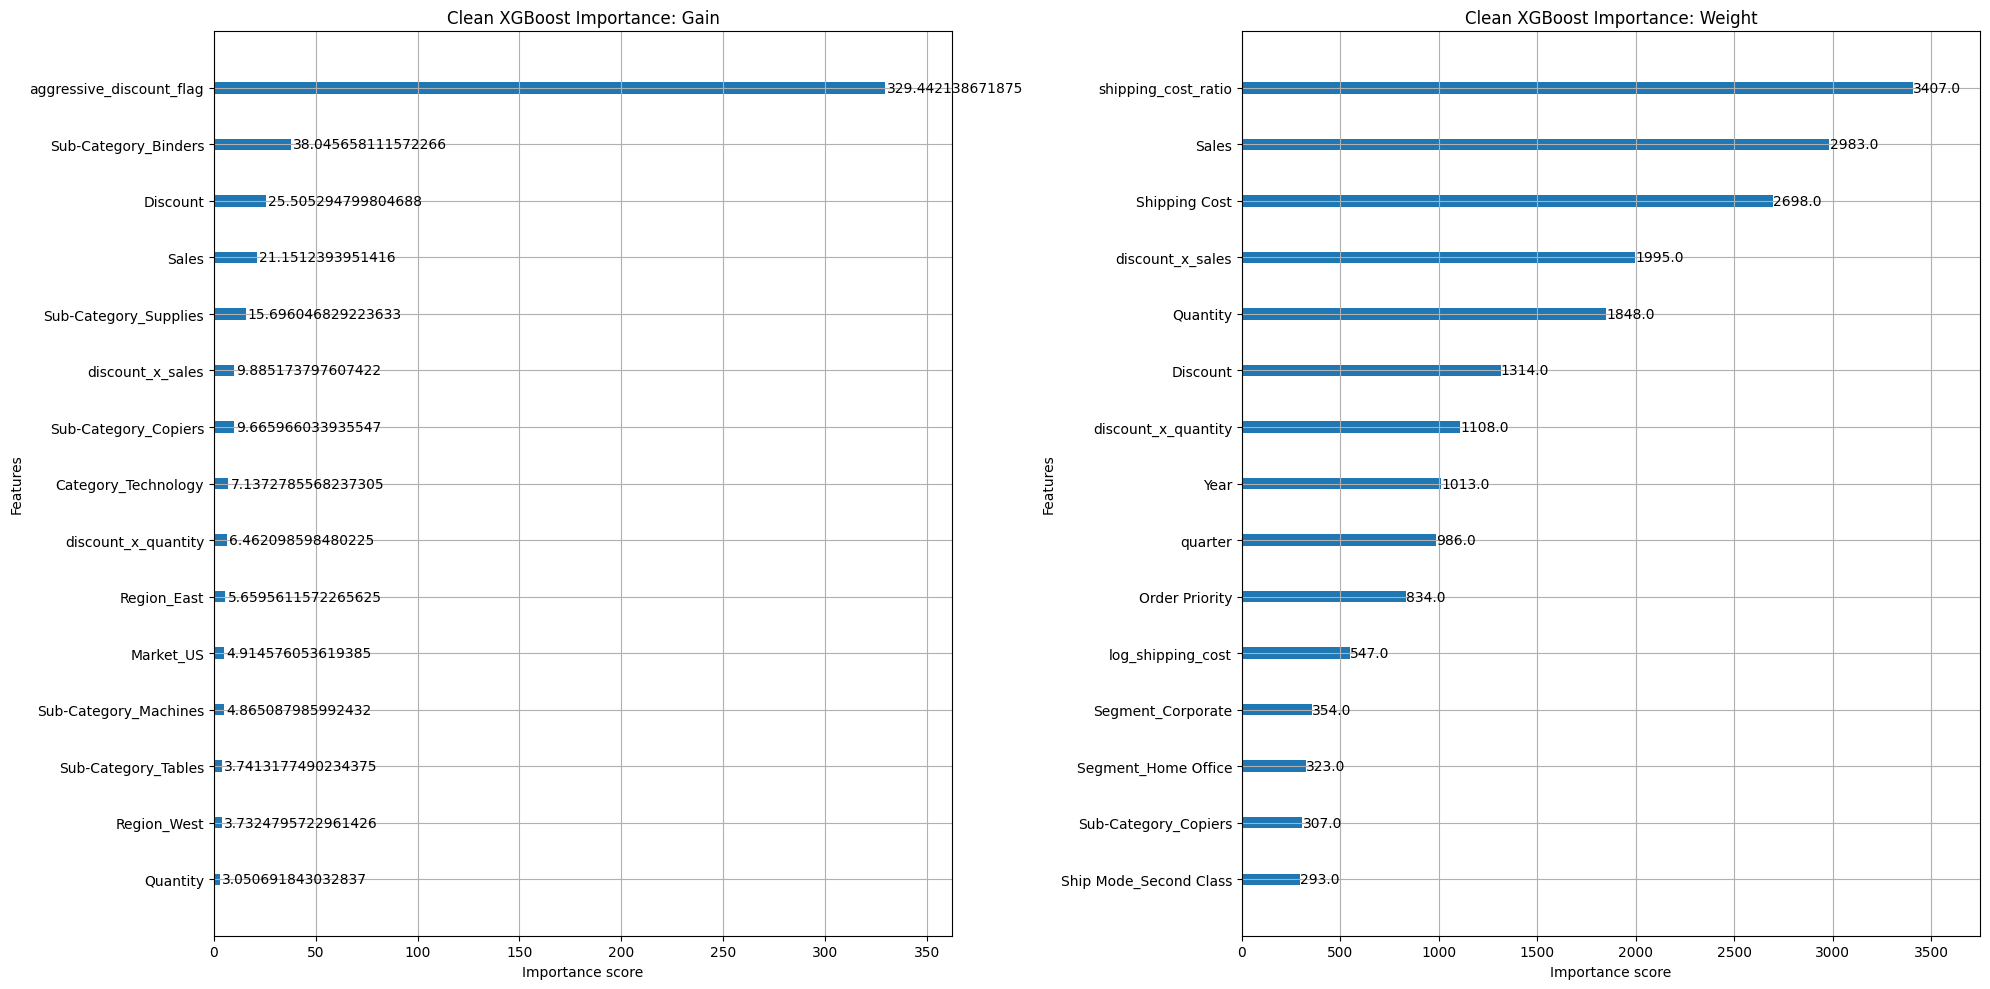

In [209]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Visualizing updated Feature Importance for the clean XGBoost model
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Gain Importance (Contribution to model accuracy)
plot_importance(clean_xgb, importance_type='gain', ax=axes[0], max_num_features=15, title='Clean XGBoost Importance: Gain')

# Weight Importance (Frequency of use in trees)
plot_importance(clean_xgb, importance_type='weight', ax=axes[1], max_num_features=15, title='Clean XGBoost Importance: Weight')

plt.tight_layout()
plt.show()

In [210]:
# 1. Remove leakage feature 'target_log' from the feature sets
if 'target_log' in X_train_f.columns:
    X_train_f = X_train_f.drop(columns=['target_log'])
    X_test_f = X_test_f.drop(columns=['target_log'])
    print("Successfully removed 'target_log' from X_train_f and X_test_f.")

# 2. Retrain Random Forest on Clean Data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

clean_rf = RandomForestRegressor(
    max_depth=20,
    max_features='sqrt',
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
clean_rf.fit(X_train_f, y_train_f)
y_pred_rf = clean_rf.predict(X_test_f)

print('\n--- Clean Random Forest Performance ---')
print(f'R2 Score: {r2_score(y_test_f, y_pred_rf):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_rf)):.4f}')

# 3. Retrain XGBoost on Clean Data
import xgboost as xgb

clean_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clean_xgb.fit(X_train_f, y_train_f)
y_pred_xgb = clean_xgb.predict(X_test_f)

print('\n--- Clean XGBoost Performance ---')
print(f'R2 Score: {r2_score(y_test_f, y_pred_xgb):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_f, y_pred_xgb)):.4f}')


--- Clean Random Forest Performance ---
R2 Score: 0.6706
RMSE: 0.5676

--- Clean XGBoost Performance ---
R2 Score: 0.6549
RMSE: 0.5810
